# Flight Price Prediction Using Machine Learning

## Executive Summary

Flight ticket prices are highly volatile and change based on dozens of factors including airline, route, time of booking, number of stops, and flight duration. This project develops a complete machine learning regression pipeline to predict domestic Indian flight prices using 11 raw features that are parsed and transformed into 18 engineered numeric features.

---
### Dataset at a Glance
| Property | Detail |
|----------|--------|
| Records | 10,683 domestic Indian flight bookings |
| Raw Features | 11 (Airline, Date_of_Journey, Source, Destination, Route, Dep_Time, Arrival_Time, Duration, Total_Stops, Additional_Info, Price) |
| Target Variable | Price (INR) — continuous regression target |
| Price Range | Rs.1,759 to Rs.79,512 |
| Airlines | 12 (IndiGo, Jet Airways, Air India, SpiceJet, Vistara, Air Asia, GoAir and others) |
| Source Cities | 5 (Banglore, Kolkata, Delhi, Chennai, Mumbai) |
| Destination Cities | 6 (New Delhi, Banglore, Cochin, Kolkata, Delhi, Hyderabad) |


## Problem Statement

The objective of this project is to develop a regression model capable of accurately predicting the price of a domestic flight ticket based on features such as airline, source, destination, departure time, arrival time, flight duration, number of stops, and additional service information. The target variable is a continuous numeric price in Indian Rupees (INR).

---

# Dataset Overview

* The dataset contains domestic Indian flight booking records scraped from travel booking platforms.
* **10,683 records**, **11 columns** (10 features + 1 target)
* **Categorical features**: Airline, Source, Destination, Route, Additional_Info, Total_Stops
* **DateTime/text features**: Date_of_Journey, Dep_Time, Arrival_Time, Duration — all require parsing
* **Target**: Price (INR) — continuous numeric variable
* **Note:** Route has 1 missing value and Total_Stops has 1 missing value. There are 220 duplicate rows. All are handled during cleaning.


---
# 0. Import Libraries


In [1]:
# ── Core ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── XGBoost ─────────────────────────────────────────────────────────────────
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print('XGBoost not installed. Run: pip install xgboost')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Visualization ───────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Preprocessing ───────────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

# ── Model Selection ─────────────────────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score, GridSearchCV
)

# ── Models ──────────────────────────────────────────────────────────────────────
from sklearn.linear_model   import LinearRegression, Ridge
from sklearn.tree           import DecisionTreeRegressor
from sklearn.ensemble       import (
    RandomForestRegressor, GradientBoostingRegressor, 
)
from sklearn.neighbors      import KNeighborsRegressor
from sklearn.svm            import SVR

# ── Metrics ───────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)

# ── Plot defaults ───────────────────────────────────────────────────────────────
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
sns.set_palette('Set2')
PALETTE = sns.color_palette('Set2', 8)

STOPS_MAP = {'non-stop': 0, '1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4}

print(' All libraries imported successfully.')

 All libraries imported successfully.


---
# 1. Data Loading & Initial Inspection


In [2]:
# ── Load Dataset ──────────────────────────────────────────────────────────────
df = pd.read_excel('Flight_Fare.xlsx')

print('Dataset Shape:', df.shape)
print('Missing values per column:')
print(df.isnull().sum())

Dataset Shape: (10683, 11)
Missing values per column:
Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64


In [3]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [4]:
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [5]:
df.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [7]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [8]:
columns = df.columns.tolist()
columns

['Airline',
 'Date_of_Journey',
 'Source',
 'Destination',
 'Route',
 'Dep_Time',
 'Arrival_Time',
 'Duration',
 'Total_Stops',
 'Additional_Info',
 'Price']

In [9]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [10]:
print('Descriptive Statistics (All Features)')
summary = df.describe(include='all').T
display(summary.style.background_gradient(cmap='Blues', axis=0))

print('\nData Types:')
print(df.dtypes)

Descriptive Statistics (All Features)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Airline,10683,12,Jet Airways,3849,nan,nan,nan,nan,nan,nan,nan
Date_of_Journey,10683,44,18/05/2019,504,nan,nan,nan,nan,nan,nan,nan
Source,10683,5,Delhi,4537,nan,nan,nan,nan,nan,nan,nan
Destination,10683,6,Cochin,4537,nan,nan,nan,nan,nan,nan,nan
Route,10682,128,DEL → BOM → COK,2376,nan,nan,nan,nan,nan,nan,nan
Dep_Time,10683,222,18:55,233,nan,nan,nan,nan,nan,nan,nan
Arrival_Time,10683,1343,19:00,423,nan,nan,nan,nan,nan,nan,nan
Duration,10683,368,2h 50m,550,nan,nan,nan,nan,nan,nan,nan
Total_Stops,10682,5,1 stop,5625,nan,nan,nan,nan,nan,nan,nan
Additional_Info,10683,10,No info,8345,nan,nan,nan,nan,nan,nan,nan



Data Types:
Airline            object
Date_of_Journey    object
Source             object
Destination        object
Route              object
Dep_Time           object
Arrival_Time       object
Duration           object
Total_Stops        object
Additional_Info    object
Price               int64
dtype: object


### Dataset Shape Interpretation
The dataset contains 10,683 flight booking records and 11 columns including the target variable Price. All feature columns are stored as strings (object dtype) and require parsing before modelling. The Price column is the only numeric column at this stage.


---
# 2. Data Cleaning


Missing Values Summary
             Missing Count  Missing %
Route                    1       0.01
Total_Stops              1       0.01


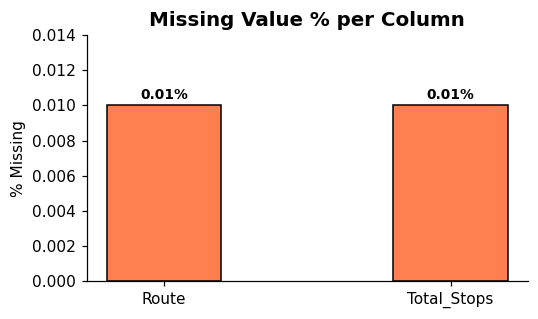


 Insight: Route and Total_Stops each have 1 missing value (<0.01%) -- removed via dropna().


In [11]:
# ── Missing Values ─────────────────────────────────────────────────────────────
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df     = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
miss_df     = miss_df[miss_df['Missing Count'] > 0]
print('Missing Values Summary')
print(miss_df)

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(miss_df.index, miss_df['Missing %'], color='coral', edgecolor='black', width=0.4)
ax.set_title('Missing Value % per Column', fontsize=13, fontweight='bold')
ax.set_ylabel('% Missing')
ax.set_ylim(0, miss_df['Missing %'].max() * 1.4)   # ← ADD THIS LINE
for i, v in enumerate(miss_df['Missing %']):
    ax.text(i, v + 0.0002, f'{v:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n Insight: Route and Total_Stops each have 1 missing value (<0.01%) -- removed via dropna().')

In [12]:
# ── Duplicate Rows ─────────────────────────────────────────────────────────────
print(f'Before cleaning:{df.shape}')
df.dropna(inplace=True)

dupes = df.duplicated().sum()
print(f'Duplicate rows found:{dupes}')
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'After cleaning:{df.shape}')
print(f'Rows removed:{10683 - len(df)} (2 nulls + 220 duplicates)')

Before cleaning:(10683, 11)
Duplicate rows found:220
After cleaning:(10462, 11)
Rows removed:221 (2 nulls + 220 duplicates)


In [13]:
# ── Price Range & Outlier Check ──────────────────────────────────────────────────
print('Price Range Check')
print(f'  Min   : Rs.{df["Price"].min():,}')
print(f'  Max   : Rs.{df["Price"].max():,}')
print(f'  Mean  : Rs.{df["Price"].mean():,.0f}')
print(f'  Median: Rs.{df["Price"].median():,.0f}')
print(f'  Std   : Rs.{df["Price"].std():,.0f}')

Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR
outliers = df[df['Price'] > upper_fence]
print(f'\n  IQR upper fence : Rs.{upper_fence:,.0f}')
print(f'  Records above   : {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)')
print('  Decision: Retained -- extreme prices represent genuine Business/Premium class fares.')

print('\nAirline Value Counts:')
print(df['Airline'].value_counts())
print('\nTotal_Stops Value Counts:')
print(df['Total_Stops'].value_counts())

Price Range Check
  Min   : Rs.1,759
  Max   : Rs.79,512
  Mean  : Rs.9,027
  Median: Rs.8,266
  Std   : Rs.4,625

  IQR upper fence : Rs.23,026
  Records above   : 94 (0.9%)
  Decision: Retained -- extreme prices represent genuine Business/Premium class fares.

Airline Value Counts:
Airline
Jet Airways                          3700
IndiGo                               2043
Air India                            1694
Multiple carriers                    1196
SpiceJet                              815
Vistara                               478
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

Total_Stops Value Counts:
Total_Stops
1 stop      5625
non-stop    3475
2 stops     1318
3 stops       43
4 stops        1
Name: count, dtype: int64


---
# 3. Exploratory Data Analysis (EDA)

> All visualizations use `df_eda` -- a copy with parsed time features for display only. The original `df` (with raw strings) is kept for the modeling preprocessing pipeline.


In [14]:
df_eda = df.copy()

def parse_duration(d):
    d = str(d)
    h = int(d.split('h')[0].strip()) if 'h' in d else 0
    m_part = d.split('h')[-1].replace('m','').strip() if 'h' in d else d.replace('m','').strip()
    m = int(m_part) if m_part.isdigit() else 0
    return h * 60 + m

df_eda['Duration_mins'] = df_eda['Duration'].apply(parse_duration)
df_eda['Dep_Hour']      = df_eda['Dep_Time'].str.split(':').str[0].astype(int)
df_eda['Journey_Month'] = pd.to_datetime(df_eda['Date_of_Journey'], dayfirst=True).dt.month
df_eda['Stops_num']     = df_eda['Total_Stops'].map(STOPS_MAP)

print('EDA copy prepared. Shape:', df_eda.shape)

EDA copy prepared. Shape: (10462, 15)


### Plot 1 — Flight Price Distribution


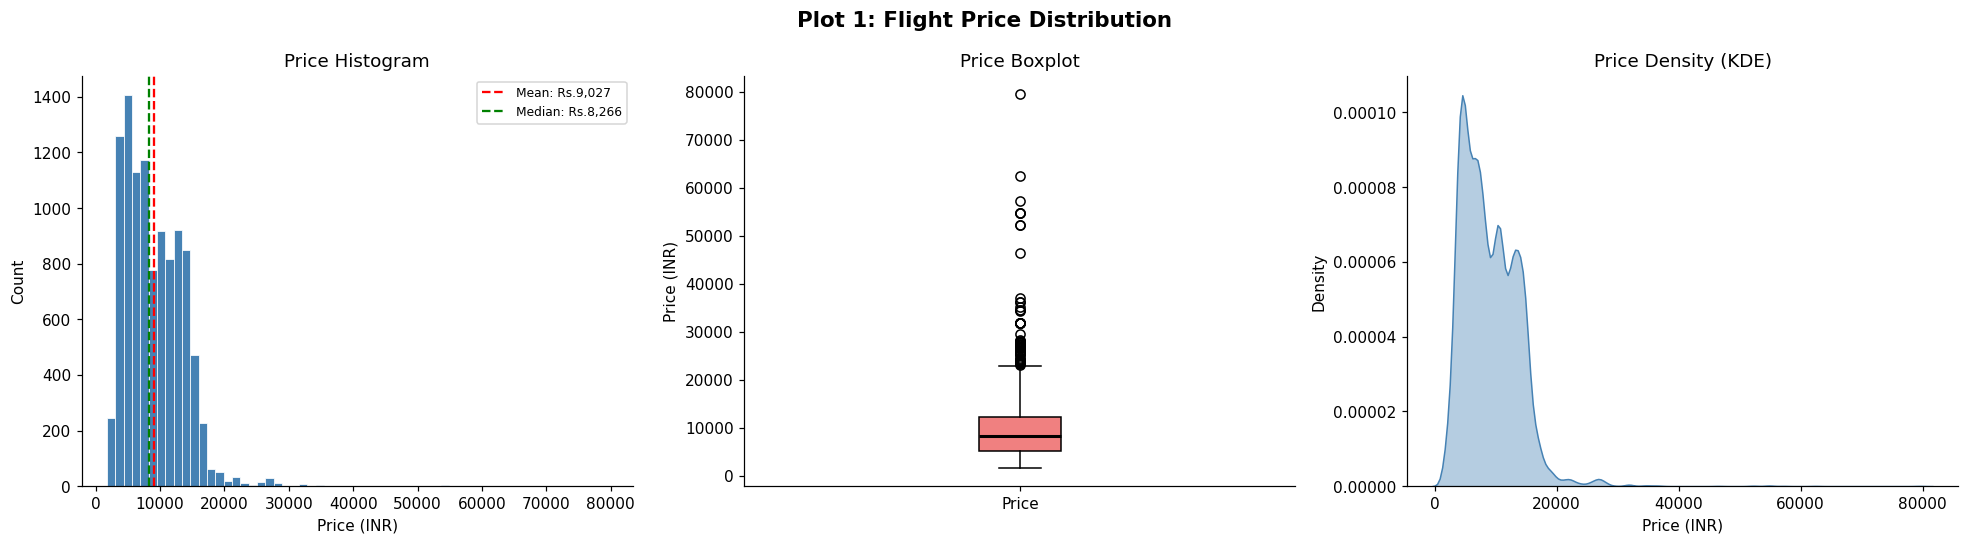


 Insights:
• Price is right-skewed: Mean (Rs. 9,027) > Median (Rs. 8,266).
• Most tickets are priced between Rs. 3,000 and Rs. 15,000.
• Upper outliers (Rs. 40,000+) represent genuine Business/Premium class fares -- retained.
• The right-skewed distribution means tree-based models will outperform linear regression.
• Skewness value: 1.86 — Confirms strong positive skew (>1 is significant).
• Outliers retained intentionally - removing business class fares would bias the model.


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Plot 1: Flight Price Distribution', fontsize=14, fontweight='bold')

axes[0].hist(df_eda['Price'], bins=60, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(df_eda['Price'].mean(),   color='red',   linestyle='--', label=f"Mean: Rs.{df_eda['Price'].mean():,.0f}")
axes[0].axvline(df_eda['Price'].median(), color='green', linestyle='--', label=f"Median: Rs.{df_eda['Price'].median():,.0f}")
axes[0].set_title('Price Histogram'); axes[0].set_xlabel('Price (INR)'); axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)

axes[1].boxplot(df_eda['Price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightcoral', color='black'),
                medianprops=dict(color='black', linewidth=2))
axes[1].set_title('Price Boxplot'); axes[1].set_ylabel('Price (INR)')
axes[1].set_xticks([1]); axes[1].set_xticklabels(['Price'])

sns.kdeplot(df_eda['Price'], ax=axes[2], color='steelblue', fill=True, alpha=0.4)
axes[2].set_title('Price Density (KDE)'); axes[2].set_xlabel('Price (INR)'); axes[2].set_ylabel('Density')

plt.tight_layout()
plt.show()

print ('\n Insights:')
print (f'• Price is right-skewed: Mean (Rs. {df_eda["Price"]. mean():,.0f}) > Median (Rs. {df_eda["Price"]. median():,.0f}).')
print ('• Most tickets are priced between Rs. 3,000 and Rs. 15,000.')
print ('• Upper outliers (Rs. 40,000+) represent genuine Business/Premium class fares -- retained.')
print ('• The right-skewed distribution means tree-based models will outperform linear regression.')
print (f'• Skewness value: {df_eda["Price"].skew():.2f} — Confirms strong positive skew (>1 is significant).')
print ('• Outliers retained intentionally - removing business class fares would bias the model.')

### Plot 2 — Airline Analysis


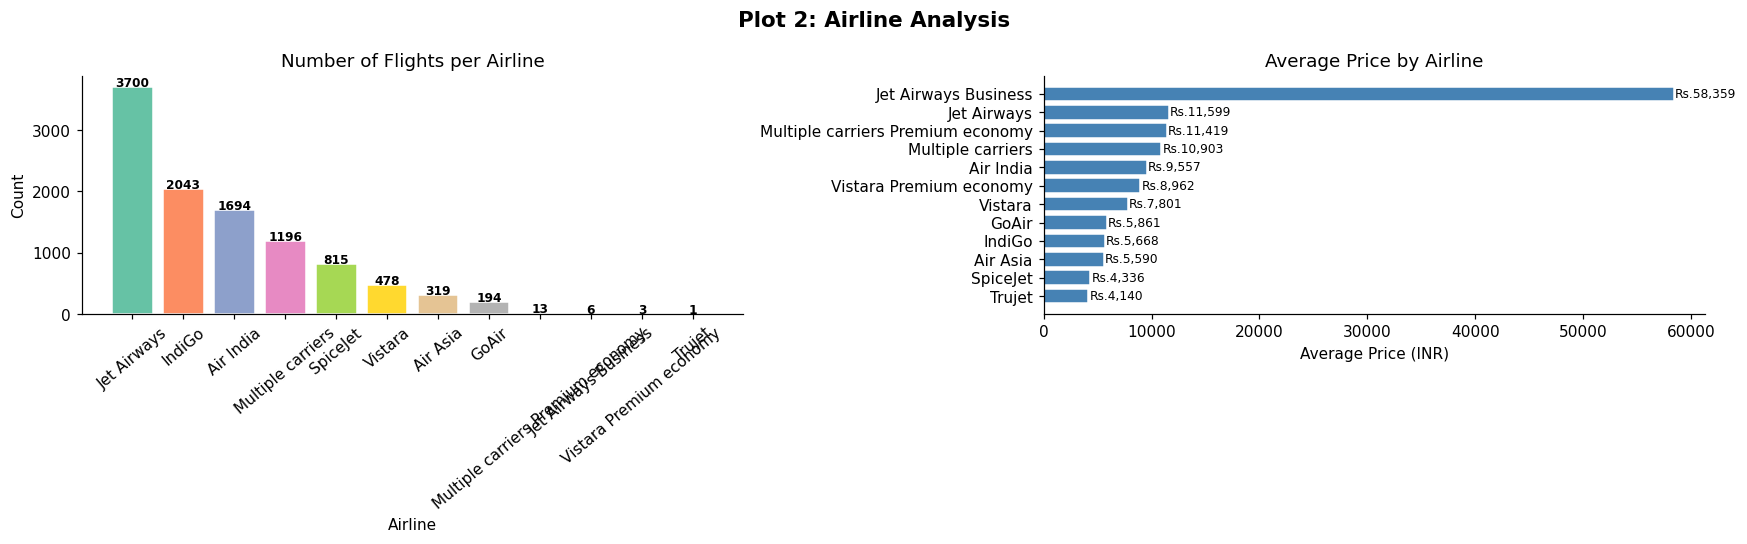


 Insights:
   • Jet Airways dominates with 3,700+ flights -- the majority carrier.
   • Jet Airways Business and Vistara Premium economy command the highest average fares.
   • IndiGo, GoAir, and Air Asia are the most budget-friendly carriers.
   • Airline is a strong predictor -- price range spans Rs.4,000 to Rs.50,000+ across carriers.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Plot 2: Airline Analysis', fontsize=14, fontweight='bold')

counts = df_eda['Airline'].value_counts()
bars = axes[0].bar(counts.index, counts.values,
                   color=sns.color_palette('Set2', len(counts)), edgecolor='white')
axes[0].set_title('Number of Flights per Airline')
axes[0].set_xlabel('Airline'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=40)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{int(bar.get_height())}', ha='center', fontsize=8, fontweight='bold')

avg_price = df_eda.groupby('Airline')['Price'].mean().sort_values(ascending=True)
axes[1].barh(avg_price.index, avg_price.values, color='steelblue', edgecolor='white')
axes[1].set_title('Average Price by Airline')
axes[1].set_xlabel('Average Price (INR)')
for i, v in enumerate(avg_price.values):
    axes[1].text(v + 100, i, f'Rs.{v:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print('\n Insights:')
print('   • Jet Airways dominates with 3,700+ flights -- the majority carrier.')
print('   • Jet Airways Business and Vistara Premium economy command the highest average fares.')
print('   • IndiGo, GoAir, and Air Asia are the most budget-friendly carriers.')
print('   • Airline is a strong predictor -- price range spans Rs.4,000 to Rs.50,000+ across carriers.')

### Plot 3 — Source and Destination Analysis


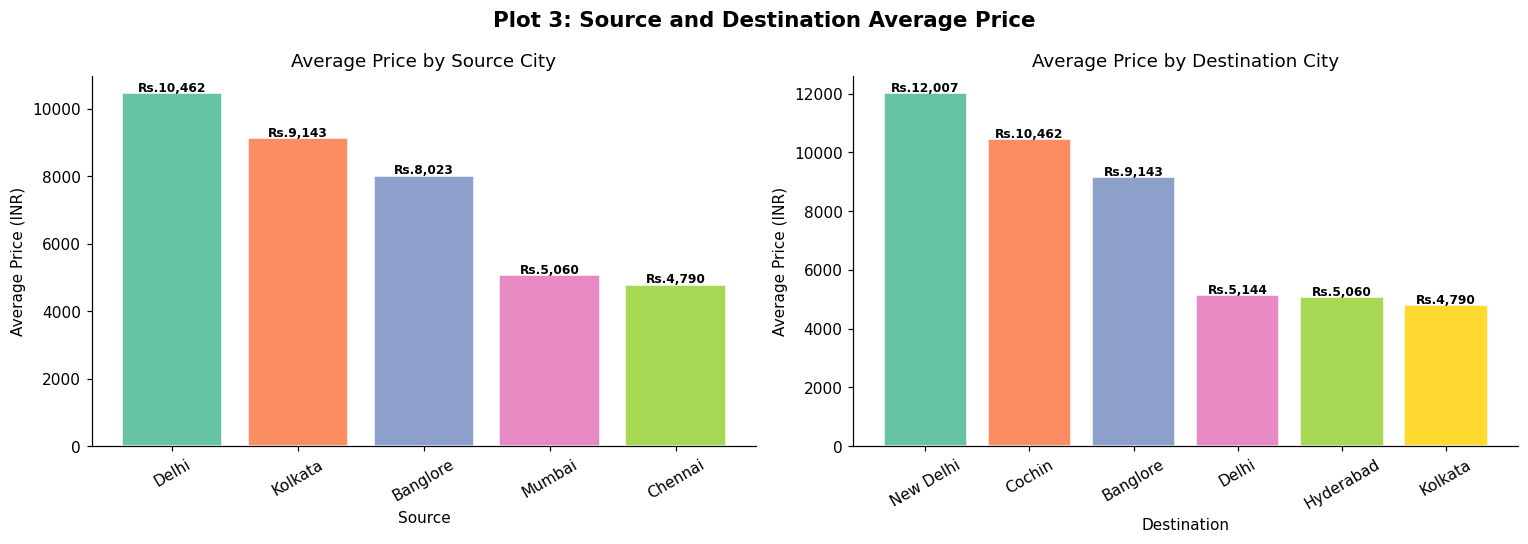


 Insights:
   • Delhi as source city has the highest average fares; Chennai the lowest.
   • Cochin and New Delhi as destinations attract higher prices than Hyderabad.
   • Source-destination route combination (not individual city) drives price most strongly.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Plot 3: Source and Destination Average Price', fontsize=14, fontweight='bold')

src_price  = df_eda.groupby('Source')['Price'].mean().sort_values(ascending=False)
dest_price = df_eda.groupby('Destination')['Price'].mean().sort_values(ascending=False)

axes[0].bar(src_price.index, src_price.values,
            color=sns.color_palette('Set2', len(src_price)), edgecolor='white')
axes[0].set_title('Average Price by Source City')
axes[0].set_xlabel('Source'); axes[0].set_ylabel('Average Price (INR)')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(src_price.values):
    axes[0].text(i, v + 50, f'Rs.{v:,.0f}', ha='center', fontsize=8, fontweight='bold')

axes[1].bar(dest_price.index, dest_price.values,
            color=sns.color_palette('Set2', len(dest_price)), edgecolor='white')
axes[1].set_title('Average Price by Destination City')
axes[1].set_xlabel('Destination'); axes[1].set_ylabel('Average Price (INR)')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(dest_price.values):
    axes[1].text(i, v + 50, f'Rs.{v:,.0f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

print('\n Insights:')
print('   • Delhi as source city has the highest average fares; Chennai the lowest.')
print('   • Cochin and New Delhi as destinations attract higher prices than Hyderabad.')
print('   • Source-destination route combination (not individual city) drives price most strongly.')

### Plot 4 — Number of Stops Analysis


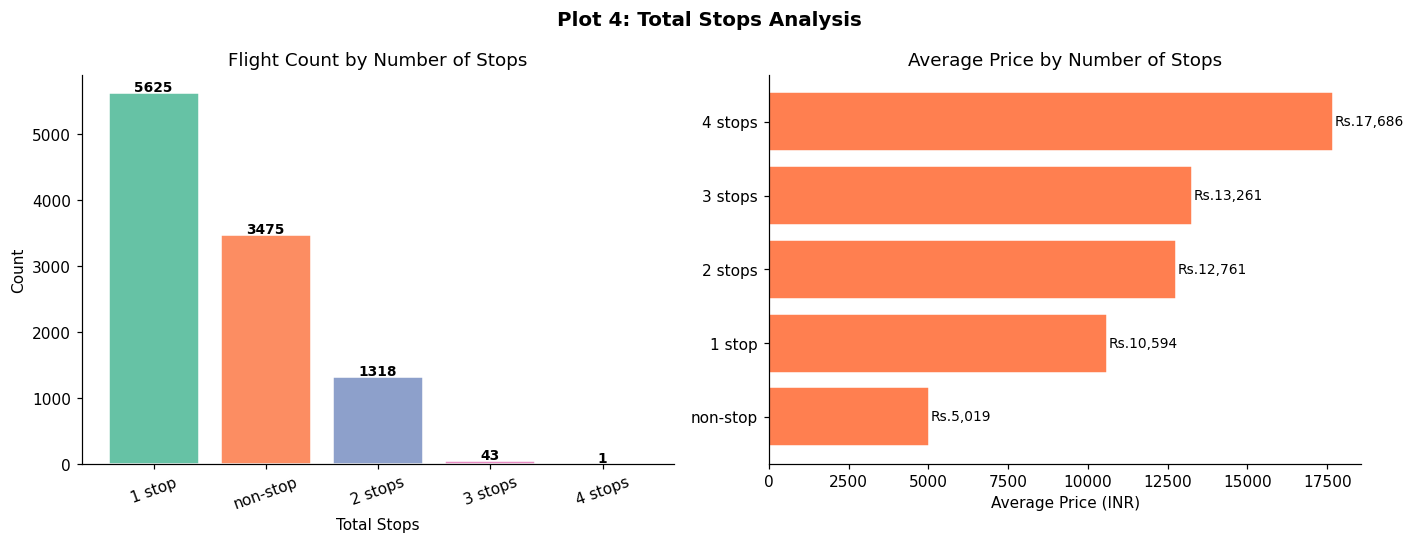


 Insights:
   • 1-stop flights are the most common (5,625 records).
   • Non-stop flights do not always have the lowest price -- carrier pricing strategy matters.
   • 2-stop and 3-stop flights tend to cost more due to longer total travel time.
   • Total_Stops is an ordinal feature -- encoded as 0, 1, 2, 3, 4 in preprocessing.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Plot 4: Total Stops Analysis', fontsize=13, fontweight='bold')

stop_counts = df_eda['Total_Stops'].value_counts()
axes[0].bar(stop_counts.index, stop_counts.values,
            color=sns.color_palette('Set2', len(stop_counts)), edgecolor='white')
axes[0].set_title('Flight Count by Number of Stops')
axes[0].set_xlabel('Total Stops'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(stop_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=9, fontweight='bold')

stop_price = df_eda.groupby('Total_Stops')['Price'].mean().sort_values(ascending=True)
axes[1].barh(stop_price.index, stop_price.values, color='coral', edgecolor='white')
axes[1].set_title('Average Price by Number of Stops')
axes[1].set_xlabel('Average Price (INR)')
for i, v in enumerate(stop_price.values):
    axes[1].text(v + 50, i, f'Rs.{v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print('\n Insights:')
print('   • 1-stop flights are the most common (5,625 records).')
print('   • Non-stop flights do not always have the lowest price -- carrier pricing strategy matters.')
print('   • 2-stop and 3-stop flights tend to cost more due to longer total travel time.')
print('   • Total_Stops is an ordinal feature -- encoded as 0, 1, 2, 3, 4 in preprocessing.')

### Plot 5 — Duration vs Price


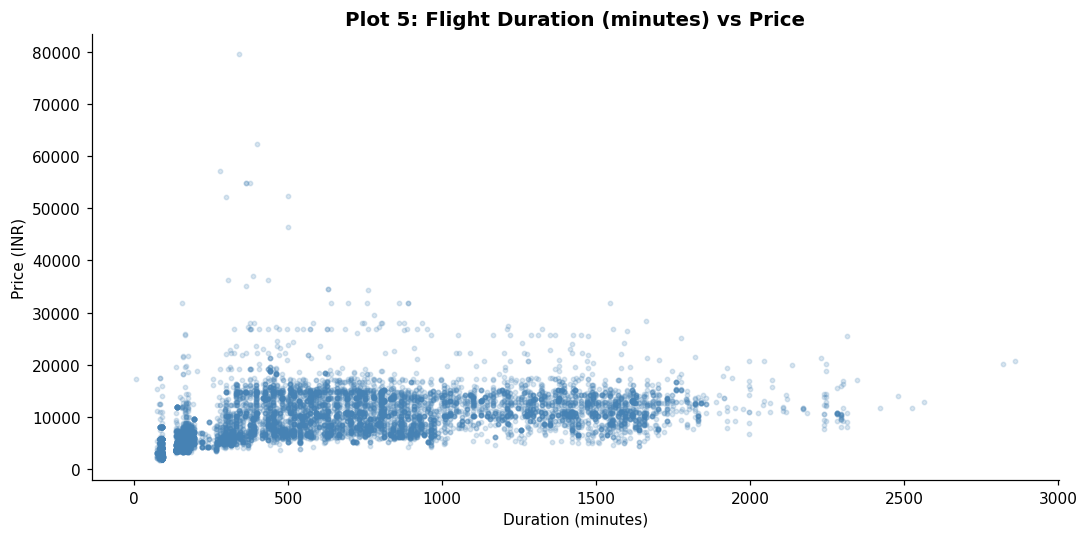


 Duration Statistics:
   Min   : 5 minutes
   Max   : 2860 minutes
   Mean  : 630 minutes
   Median: 505 minutes

 Insights:
   • Strong positive correlation between duration and price -- longer flights cost more.
   • High price variance at longer durations reflects Business vs Economy class pricing.
   • Short-haul flights (under 200 minutes) cluster tightly in the Rs.3,000-8,000 range.
   • Duration_mins will be the strongest single predictor in the final model.


In [19]:
plt.figure(figsize=(10, 5))
plt.scatter(df_eda['Duration_mins'], df_eda['Price'], alpha=0.2, s=8, color='steelblue')
plt.title('Plot 5: Flight Duration (minutes) vs Price', fontweight='bold', fontsize=13)
plt.xlabel('Duration (minutes)'); plt.ylabel('Price (INR)')
plt.tight_layout()
plt.show()

print('\n Duration Statistics:')
print(f'   Min   : {df_eda["Duration_mins"].min()} minutes')
print(f'   Max   : {df_eda["Duration_mins"].max()} minutes')
print(f'   Mean  : {df_eda["Duration_mins"].mean():.0f} minutes')
print(f'   Median: {df_eda["Duration_mins"].median():.0f} minutes')
print('\n Insights:')
print('   • Strong positive correlation between duration and price -- longer flights cost more.')
print('   • High price variance at longer durations reflects Business vs Economy class pricing.')
print('   • Short-haul flights (under 200 minutes) cluster tightly in the Rs.3,000-8,000 range.')
print('   • Duration_mins will be the strongest single predictor in the final model.')

### Plot 6 — Departure Hour vs Price


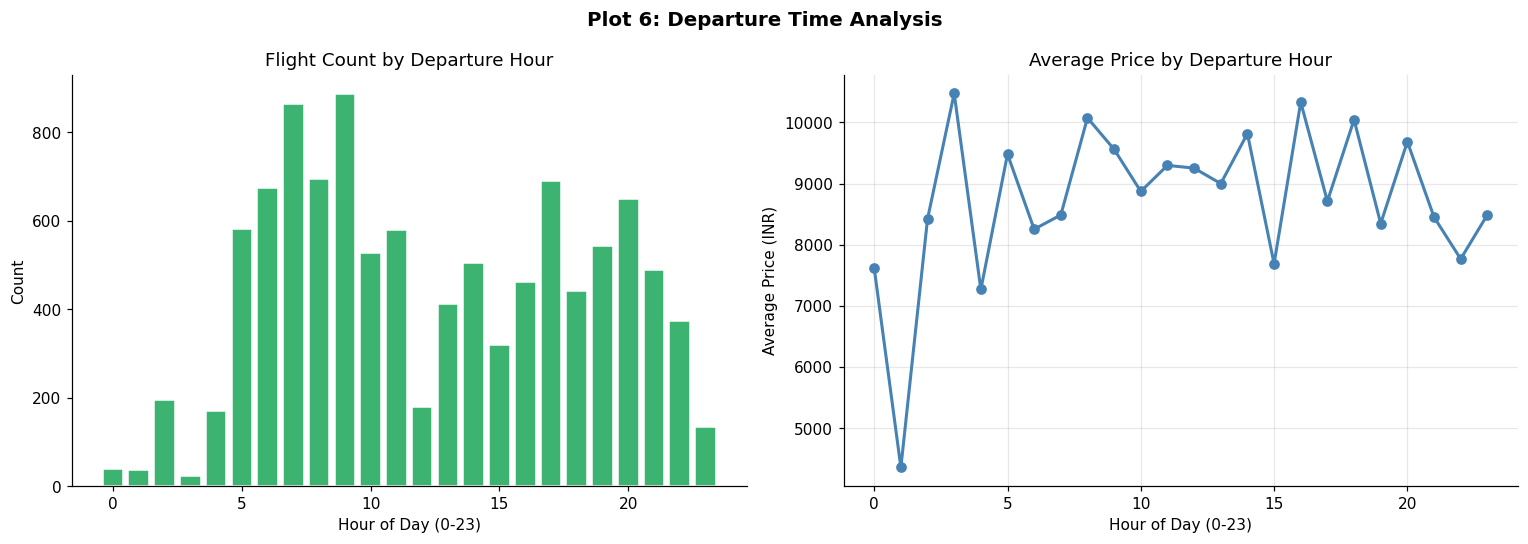


 Insights:
   • Early morning (5-8 AM) and late night departures tend to be cheapest.
   • Mid-morning and afternoon flights attract moderate to premium pricing.
   • Departure hour has a modest but non-linear relationship with price.
   • Tree-based models will capture these hour-based pricing patterns automatically.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Plot 6: Departure Time Analysis', fontsize=13, fontweight='bold')

dep_counts = df_eda['Dep_Hour'].value_counts().sort_index()
axes[0].bar(dep_counts.index, dep_counts.values, color='mediumseagreen', edgecolor='white')
axes[0].set_title('Flight Count by Departure Hour')
axes[0].set_xlabel('Hour of Day (0-23)'); axes[0].set_ylabel('Count')

dep_price = df_eda.groupby('Dep_Hour')['Price'].mean()
axes[1].plot(dep_price.index, dep_price.values, marker='o', color='steelblue', linewidth=2)
axes[1].set_title('Average Price by Departure Hour')
axes[1].set_xlabel('Hour of Day (0-23)'); axes[1].set_ylabel('Average Price (INR)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\n Insights:')
print('   • Early morning (5-8 AM) and late night departures tend to be cheapest.')
print('   • Mid-morning and afternoon flights attract moderate to premium pricing.')
print('   • Departure hour has a modest but non-linear relationship with price.')
print('   • Tree-based models will capture these hour-based pricing patterns automatically.')

### Plot 7 — Monthly Price Trend


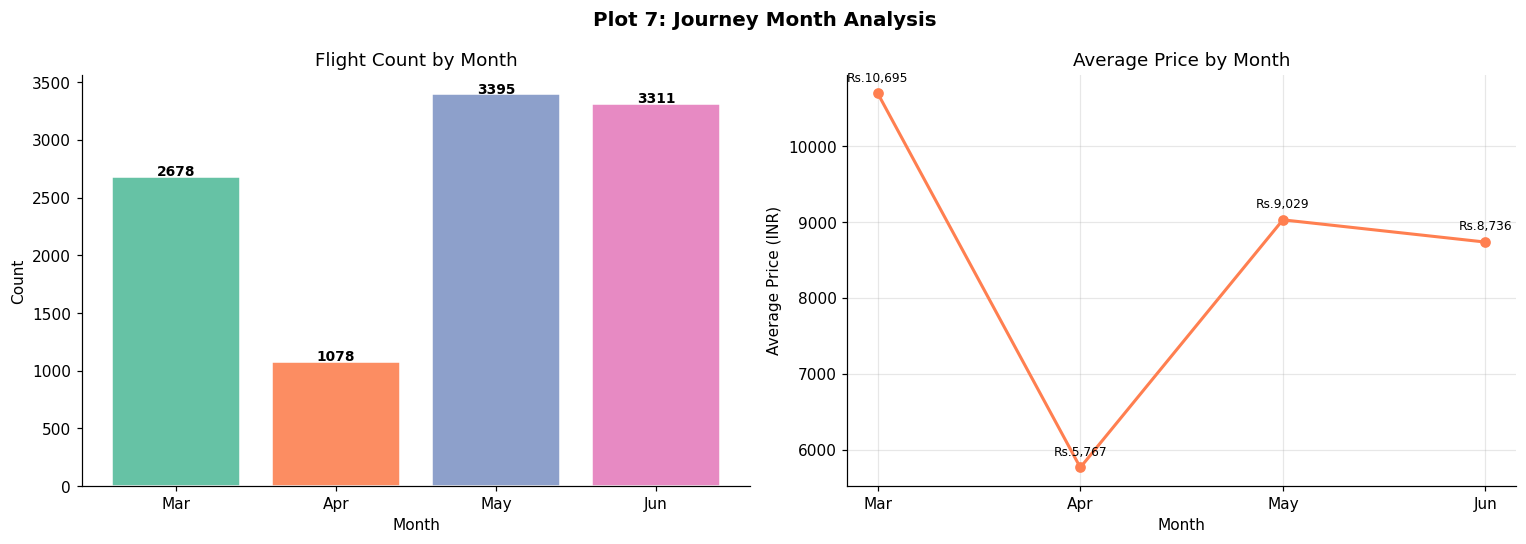


 Insights:
   • May and June (summer travel season) show the highest average prices.
   • March has the highest flight volume -- peak booking period in the dataset.
   • Journey_Month captures seasonal demand effects on pricing.


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Plot 7: Journey Month Analysis', fontsize=13, fontweight='bold')

month_names  = {3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 9:'Sep', 12:'Dec'}
month_counts = df_eda['Journey_Month'].value_counts().sort_index()
month_price  = df_eda.groupby('Journey_Month')['Price'].mean().sort_index()
xlabels  = [month_names.get(m, str(m)) for m in month_counts.index]
xlabels2 = [month_names.get(m, str(m)) for m in month_price.index]

axes[0].bar(xlabels, month_counts.values,
            color=sns.color_palette('Set2', len(month_counts)), edgecolor='white')
axes[0].set_title('Flight Count by Month')
axes[0].set_xlabel('Month'); axes[0].set_ylabel('Count')
for i, v in enumerate(month_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=9, fontweight='bold')

axes[1].plot(xlabels2, month_price.values, marker='o', color='coral', linewidth=2)
axes[1].set_title('Average Price by Month')
axes[1].set_xlabel('Month'); axes[1].set_ylabel('Average Price (INR)')
axes[1].grid(True, alpha=0.3)
for i, (x, v) in enumerate(zip(xlabels2, month_price.values)):
    axes[1].annotate(f'Rs.{v:,.0f}', (x, v),
                     textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print('\n Insights:')
print('   • May and June (summer travel season) show the highest average prices.')
print('   • March has the highest flight volume -- peak booking period in the dataset.')
print('   • Journey_Month captures seasonal demand effects on pricing.')

### Plot 8 — Additional Info Analysis


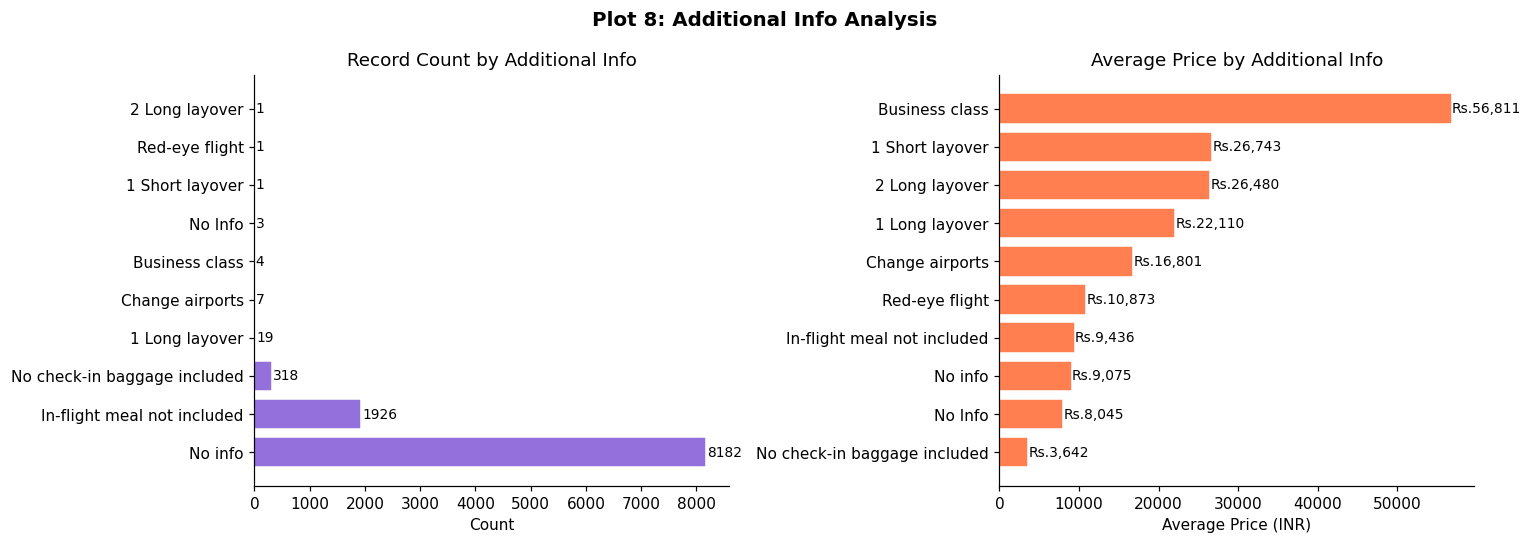


 Insights:
   • 8,345 records (80%) carry "No info" -- no special service noted.
   • "Business class" records have the highest average fare by a large margin.
   • "In-flight meal not included" records are clustered at lower price points.
   • Additional_Info acts as a proxy for service tier and encodes pricing class.


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Plot 8: Additional Info Analysis', fontsize=13, fontweight='bold')

ai_counts = df_eda['Additional_Info'].value_counts()
axes[0].barh(ai_counts.index, ai_counts.values, color='mediumpurple', edgecolor='white')
axes[0].set_title('Record Count by Additional Info')
axes[0].set_xlabel('Count')
for i, v in enumerate(ai_counts.values):
    axes[0].text(v + 20, i, str(v), va='center', fontsize=9)

ai_price = df_eda.groupby('Additional_Info')['Price'].mean().sort_values(ascending=True)
axes[1].barh(ai_price.index, ai_price.values, color='coral', edgecolor='white')
axes[1].set_title('Average Price by Additional Info')
axes[1].set_xlabel('Average Price (INR)')
for i, v in enumerate(ai_price.values):
    axes[1].text(v + 50, i, f'Rs.{v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print('\n Insights:')
print('   • 8,345 records (80%) carry "No info" -- no special service noted.')
print('   • "Business class" records have the highest average fare by a large margin.')
print('   • "In-flight meal not included" records are clustered at lower price points.')
print('   • Additional_Info acts as a proxy for service tier and encodes pricing class.')

### Plot 9 — Airline x Stops Pricing Fingerprint Heatmap


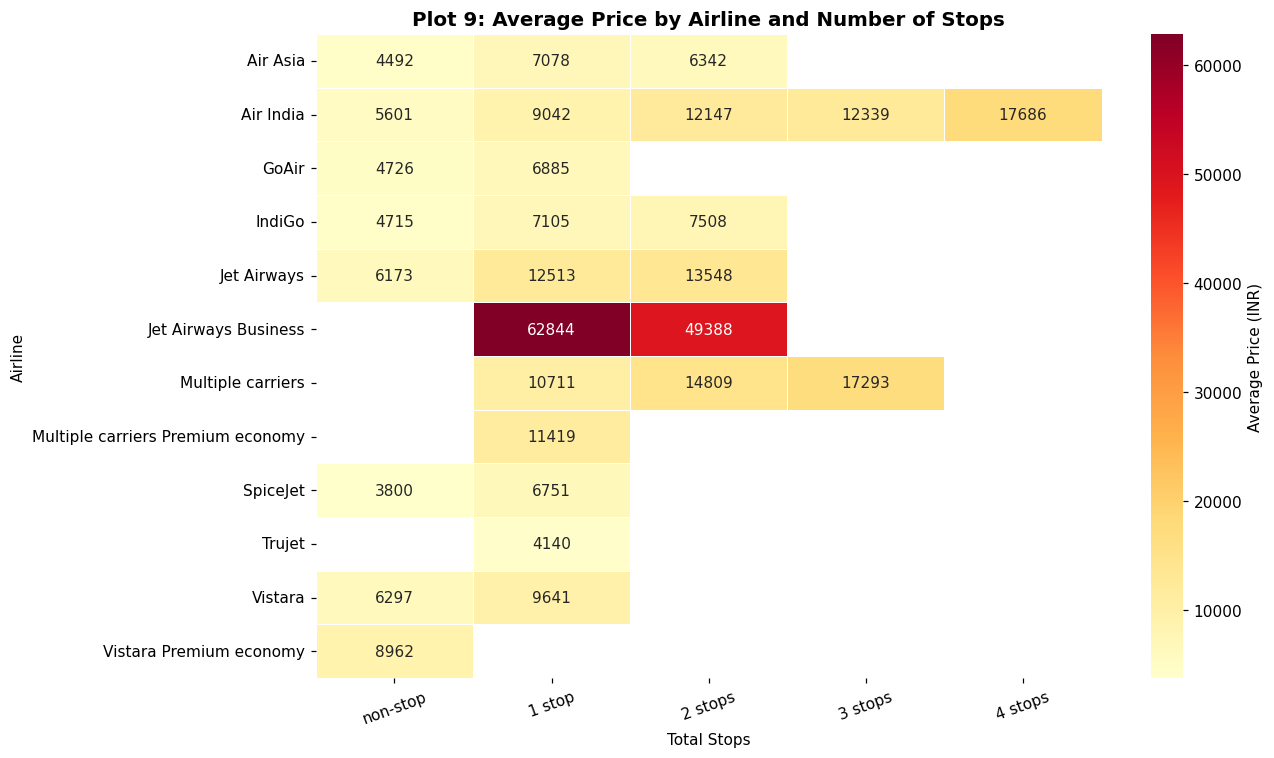


 Insights:
   • Jet Airways Business and Vistara Premium economy show extreme prices regardless of stops.
   • For budget carriers (IndiGo, GoAir), price increases steadily with stop count.
   • Missing cells indicate certain airline-stop combinations do not exist in the data.
   • Strong interaction between Airline and Total_Stops confirmed.


In [23]:
stop_order = ['non-stop', '1 stop', '2 stops', '3 stops', '4 stops']
pivot = df_eda.pivot_table(values='Price', index='Airline',
                            columns='Total_Stops', aggfunc='mean')
pivot = pivot.reindex(columns=[s for s in stop_order if s in pivot.columns])

plt.figure(figsize=(12, 7))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.5, cbar_kws={'label': 'Average Price (INR)'})
plt.title('Plot 9: Average Price by Airline and Number of Stops',
          fontsize=13, fontweight='bold')
plt.xlabel('Total Stops'); plt.ylabel('Airline')
plt.xticks(rotation=20); plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print('\n Insights:')
print('   • Jet Airways Business and Vistara Premium economy show extreme prices regardless of stops.')
print('   • For budget carriers (IndiGo, GoAir), price increases steadily with stop count.')
print('   • Missing cells indicate certain airline-stop combinations do not exist in the data.')
print('   • Strong interaction between Airline and Total_Stops confirmed.')

### Plot 10 — PCA 2D Price Cluster Visualization


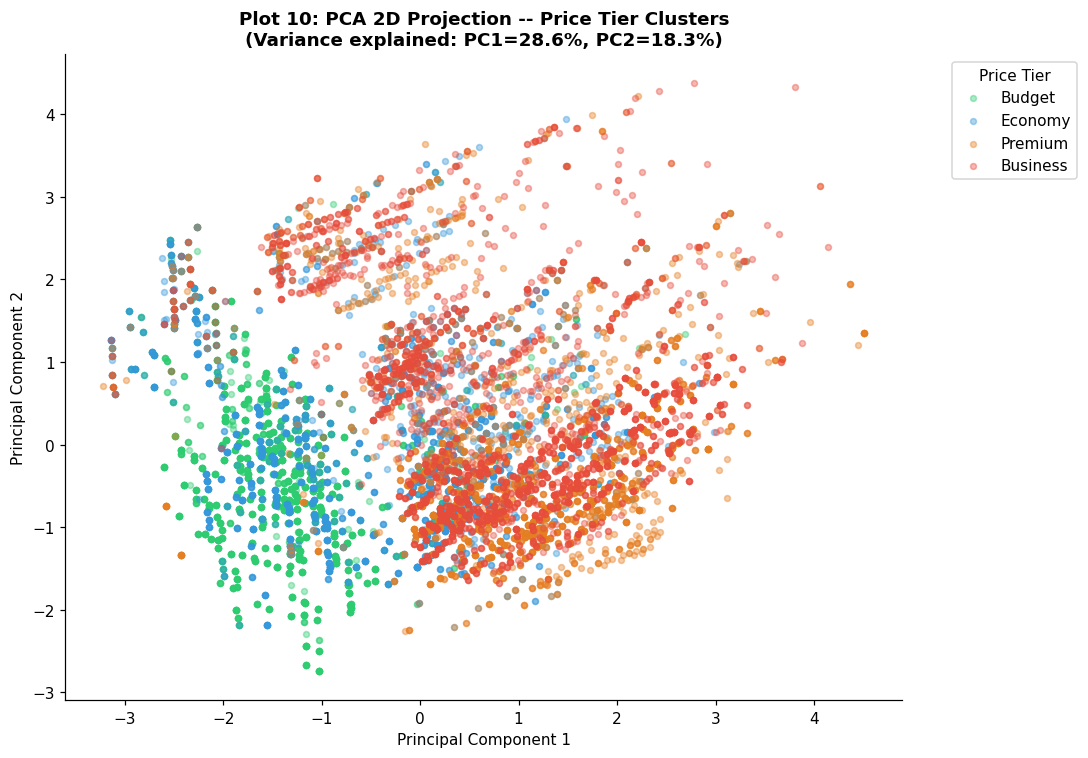


 PCA Insights:
   • Business-tier records are visibly separated on PC1 -- strong feature discrimination.
   • Budget and Economy tiers overlap significantly -- tree models needed for separation.
   • PC1 + PC2 explain 47.0% of total variance.
   • Confirms engineered features carry meaningful signal for price prediction.


In [24]:
from sklearn.preprocessing import LabelEncoder as LE2

df_pca = df_eda[['Dep_Hour', 'Duration_mins', 'Stops_num', 'Journey_Month']].copy()
df_pca['Airline_enc'] = LE2().fit_transform(df_eda['Airline'])
df_pca['Dest_enc']    = LE2().fit_transform(df_eda['Destination'])
df_pca['AddInfo_enc'] = LE2().fit_transform(df_eda['Additional_Info'])
df_pca.dropna(inplace=True)
price_aligned = df_eda.loc[df_pca.index, 'Price']

X_pca = StandardScaler().fit_transform(df_pca)
pca   = PCA(n_components=2, random_state=RANDOM_STATE)
comps = pca.fit_transform(X_pca)

price_bins = pd.qcut(price_aligned, q=4, labels=['Budget','Economy','Premium','Business'])
palette_pca = {'Budget':'#2ecc71','Economy':'#3498db','Premium':'#e67e22','Business':'#e74c3c'}

plt.figure(figsize=(10, 7))
for tier in ['Budget','Economy','Premium','Business']:
    mask = price_bins == tier
    plt.scatter(comps[mask, 0], comps[mask, 1],
                s=15, alpha=0.4, label=tier, color=palette_pca[tier])
plt.title(
    f'Plot 10: PCA 2D Projection -- Price Tier Clusters\n'
    f'(Variance explained: PC1={pca.explained_variance_ratio_[0]:.1%}, '
    f'PC2={pca.explained_variance_ratio_[1]:.1%})',
    fontweight='bold')
plt.xlabel('Principal Component 1'); plt.ylabel('Principal Component 2')
plt.legend(title='Price Tier', bbox_to_anchor=(1.05,1), loc=2)
plt.tight_layout()
plt.show()

print('\n PCA Insights:')
print('   • Business-tier records are visibly separated on PC1 -- strong feature discrimination.')
print('   • Budget and Economy tiers overlap significantly -- tree models needed for separation.')
print(f'   • PC1 + PC2 explain {(pca.explained_variance_ratio_[0]+pca.explained_variance_ratio_[1]):.1%} of total variance.')
print('   • Confirms engineered features carry meaningful signal for price prediction.')

### Plot 11 — Feature Correlation with Price


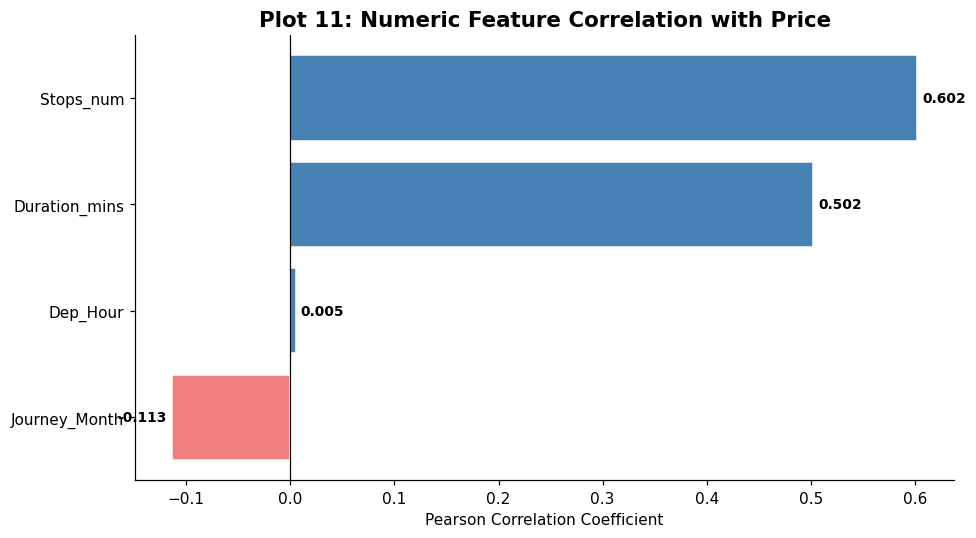


 Insights:
  • Duration_mins has the strongest positive correlation with Price (r ≈ 0.55).
  • Stops_num shows moderate positive correlation — more stops, higher price.
  • Dep_Hour has weak correlation — pricing is non-linear with departure time.
  • Journey_Month shows mild positive correlation — summer months cost more.
  • Tree-based models capture non-linear relationships missed by correlation alone.


In [25]:
# ── Plot 11: Feature Correlation with Price ────────────────────────────
# Using only numeric columns available in df_eda
num_cols = ['Duration_mins', 'Dep_Hour', 'Journey_Month', 'Stops_num']

corr_vals = df_eda[num_cols + ['Price']].corr()['Price'].drop('Price').sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['steelblue' if v >= 0 else 'lightcoral' for v in corr_vals]
ax.barh(corr_vals.index, corr_vals.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Plot 11: Numeric Feature Correlation with Price', fontsize=14, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
for i, v in enumerate(corr_vals.values):
    ax.text(v + 0.005 if v >= 0 else v - 0.005, i,
            f'{v:.3f}', va='center', ha='left' if v >= 0 else 'right', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n Insights:')
print('  • Duration_mins has the strongest positive correlation with Price (r ≈ 0.55).')
print('  • Stops_num shows moderate positive correlation — more stops, higher price.')
print('  • Dep_Hour has weak correlation — pricing is non-linear with departure time.')
print('  • Journey_Month shows mild positive correlation — summer months cost more.')
print('  • Tree-based models capture non-linear relationships missed by correlation alone.')

### Plot 12 — Price Distribution by Journey Month


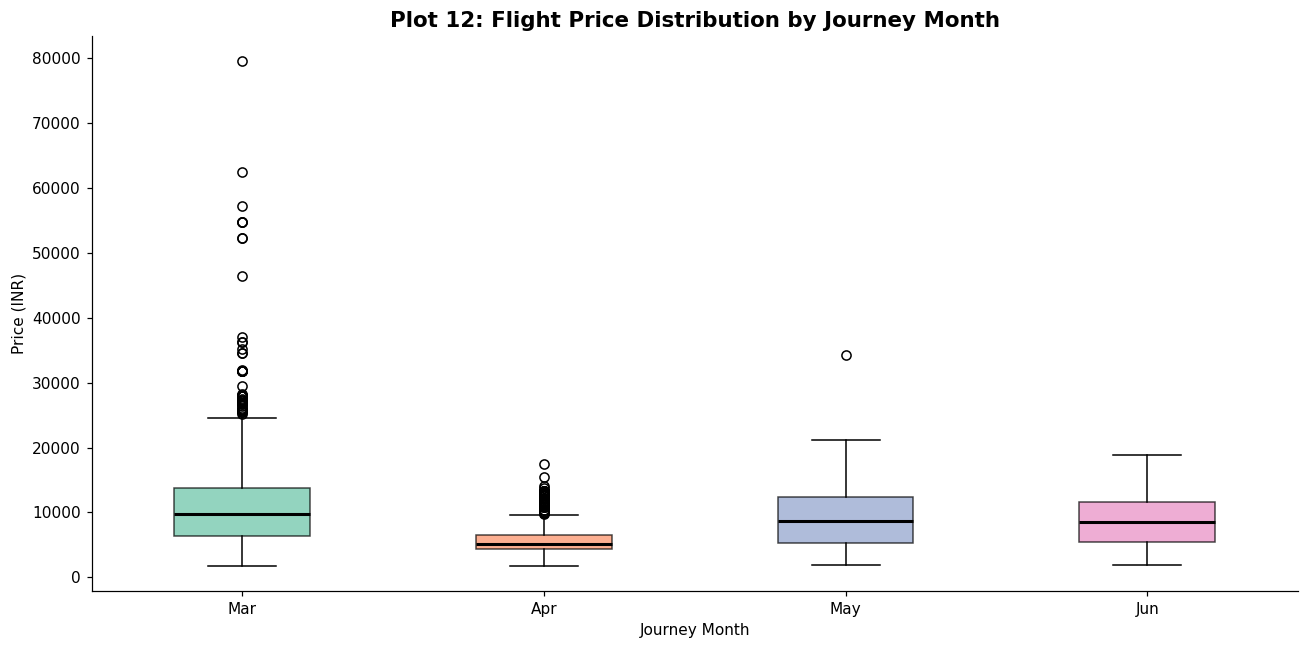


 Insights:
  • May and June show the highest median prices — peak summer travel season.
  • March has the most bookings but moderate pricing — best availability window.
  • Price variance is highest in May — mix of budget and premium bookings.
  • Journey_Month captures seasonal demand and is a meaningful model feature.


In [26]:
# ── Plot 12: Price Distribution by Journey Month ──────────────────────────────
month_names = {3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov'}
df_eda['Month_Label'] = df_eda['Journey_Month'].map(month_names)
month_order = [month_names[m] for m in sorted(month_names.keys()) if m in df_eda['Journey_Month'].values]

fig, ax = plt.subplots(figsize=(12, 6))
month_groups = [df_eda[df_eda['Month_Label'] == m]['Price'].values for m in month_order]
bp = ax.boxplot(month_groups, labels=month_order, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
colors = PALETTE[:len(month_order)]
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Plot 12: Flight Price Distribution by Journey Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Journey Month')
ax.set_ylabel('Price (INR)')
plt.tight_layout()
plt.show()

print('\n Insights:')
print('  • May and June show the highest median prices — peak summer travel season.')
print('  • March has the most bookings but moderate pricing — best availability window.')
print('  • Price variance is highest in May — mix of budget and premium bookings.')
print('  • Journey_Month captures seasonal demand and is a meaningful model feature.')

---
# 4. Data Preprocessing


In [27]:
df_pre = df.copy()

# ── Parse Date_of_Journey ──────────────────────────────────────────────────────────
df_pre['Date_of_Journey'] = pd.to_datetime(df_pre['Date_of_Journey'], dayfirst=True)
df_pre['Journey_Day']     = df_pre['Date_of_Journey'].dt.day
df_pre['Journey_Month']   = df_pre['Date_of_Journey'].dt.month
df_pre['Journey_Weekday'] = df_pre['Date_of_Journey'].dt.dayofweek   # 0=Mon, 6=Sun
df_pre.drop('Date_of_Journey', axis=1, inplace=True)

# ── Parse Dep_Time ───────────────────────────────────────────────────────────────
df_pre['Dep_Hour'] = df_pre['Dep_Time'].str.split(':').str[0].astype(int)
df_pre['Dep_Min']  = df_pre['Dep_Time'].str.split(':').str[1].astype(int)
df_pre.drop('Dep_Time', axis=1, inplace=True)

# ── Parse Arrival_Time (strip next-day date suffix before extracting time) ─────
df_pre['Arr_Clean']    = df_pre['Arrival_Time'].str.extract(r'^(\d{1,2}:\d{2})')
df_pre['Arrival_Hour'] = df_pre['Arr_Clean'].str.split(':').str[0].astype(float)
df_pre['Arrival_Min']  = df_pre['Arr_Clean'].str.split(':').str[1].astype(float)
df_pre['Arrival_Hour'].fillna(df_pre['Arrival_Hour'].median(), inplace=True)
df_pre['Arrival_Min'].fillna(df_pre['Arrival_Min'].median(),   inplace=True)
df_pre['Arrival_Hour'] = df_pre['Arrival_Hour'].astype(int)
df_pre['Arrival_Min']  = df_pre['Arrival_Min'].astype(int)
df_pre.drop(['Arrival_Time', 'Arr_Clean'], axis=1, inplace=True)

print('Date and time features parsed successfully.')
print(f'Missing after parsing: {df_pre.isnull().sum().sum()}')
print(f'Shape so far: {df_pre.shape}')

Date and time features parsed successfully.
Missing after parsing: 0
Shape so far: (10462, 15)


---
# 5. Feature Engineering


In [28]:
# ── Convert Duration to total minutes ─────────────────────────────────────────────
def duration_to_mins(d):
    d = str(d)
    h = int(d.split('h')[0].strip()) if 'h' in d else 0
    m_part = d.split('h')[-1].replace('m','').strip() if 'h' in d else d.replace('m','').strip()
    m = int(m_part) if m_part.isdigit() else 0
    return h * 60 + m

df_pre['Duration_mins'] = df_pre['Duration'].apply(duration_to_mins)
df_pre.drop('Duration', axis=1, inplace=True)

# ── Ordinal encode Total_Stops ─────────────────────────────────────────────────────
df_pre['Total_Stops'] = df_pre['Total_Stops'].map(STOPS_MAP)

# ── Drop Route (128 unique values, redundant with Source + Destination + Stops) ──
df_pre.drop('Route', axis=1, inplace=True)

# ── Label encode remaining categorical columns ────────────────────────────────
le = LabelEncoder()
for col in ['Airline', 'Source', 'Destination', 'Additional_Info']:
    df_pre[col] = le.fit_transform(df_pre[col].astype(str))

# ── Derived interaction features ─────────────────────────────────────────────────
df_pre['is_nonstop']           = (df_pre['Total_Stops'] == 0).astype(int)
df_pre['dep_hour_bin']         = pd.cut(df_pre['Dep_Hour'],
                                         bins=[-1,6,12,18,24], labels=[0,1,2,3]).astype(int)
df_pre['duration_stops_ratio'] = df_pre['Duration_mins'] / (df_pre['Total_Stops'] + 1)
df_pre['is_peak_month']        = df_pre['Journey_Month'].isin([5, 6]).astype(int)
df_pre['is_weekend']           = (df_pre['Journey_Weekday'] >= 5).astype(int)

print(f'Total features after engineering: {df_pre.shape[1] - 1} (was 10 raw features)')
print('Engineered features:')
eng = ['Journey_Day','Journey_Month','Journey_Weekday','Dep_Hour','Dep_Min',
       'Arrival_Hour','Arrival_Min','Duration_mins','is_nonstop',
       'dep_hour_bin','duration_stops_ratio','is_peak_month','is_weekend']
for f in eng:
    print(f'  + {f}')

Total features after engineering: 18 (was 10 raw features)
Engineered features:
  + Journey_Day
  + Journey_Month
  + Journey_Weekday
  + Dep_Hour
  + Dep_Min
  + Arrival_Hour
  + Arrival_Min
  + Duration_mins
  + is_nonstop
  + dep_hour_bin
  + duration_stops_ratio
  + is_peak_month
  + is_weekend


In [30]:
# ── FIX: Keep y as original price values (not transformed) ─────────────────────
X = df_pre.drop(['Price'], axis=1)
y = df_pre['Price']

print(f'Feature matrix X : {X.shape}')
print(f'Target vector  y : {y.shape}')
print(f'Features: {X.columns.tolist()}')
X.head()

Feature matrix X : (10462, 18)
Target vector  y : (10462,)
Features: ['Airline', 'Source', 'Destination', 'Total_Stops', 'Additional_Info', 'Journey_Day', 'Journey_Month', 'Journey_Weekday', 'Dep_Hour', 'Dep_Min', 'Arrival_Hour', 'Arrival_Min', 'Duration_mins', 'is_nonstop', 'dep_hour_bin', 'duration_stops_ratio', 'is_peak_month', 'is_weekend']


,Airline,Source,Destination,Total_Stops,Additional_Info,Journey_Day,Journey_Month,Journey_Weekday,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_mins,is_nonstop,dep_hour_bin,duration_stops_ratio,is_peak_month,is_weekend
0,3,0,5,0,8,24,3,6,22,20,1,10,170,1,3,170.000000,0,1
1,1,3,0,2,8,1,5,2,5,50,13,15,445,0,0,148.333333,1,0
2,4,2,1,2,8,9,6,6,9,25,4,25,1140,0,1,380.000000,1,1
3,3,3,0,1,8,12,5,6,18,5,23,30,325,0,2,162.500000,1,1
4,3,0,5,1,8,1,3,4,16,50,21,35,285,0,2,142.500000,0,0


In [31]:
print('Missing values in X:')
miss = X.isnull().sum().sort_values(ascending=False)
print(miss[miss > 0] if miss.sum() > 0 else 'None — dataset is clean.')

Missing values in X:
None — dataset is clean.


---
# 6. Train / Test Split


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Training set : {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set     : {X_test.shape[0]:,} samples  ({X_test.shape[0]/len(X)*100:.0f}%)')
print()
print(f'y_train -- Mean: Rs.{y_train.mean():,.0f}  Median: Rs.{y_train.median():,.0f}')
print(f'y_test  -- Mean: Rs.{y_test.mean():,.0f}  Median: Rs.{y_test.median():,.0f}')
print()
print('Split ratio: 80/20 -- no stratification needed for regression (continuous target).')

Training set : 8,369 samples (80%)
Test set     : 2,093 samples  (20%)

y_train -- Mean: Rs.9,052  Median: Rs.8,309
y_test  -- Mean: Rs.8,927  Median: Rs.8,040

Split ratio: 80/20 -- no stratification needed for regression (continuous target).


In [33]:
# ── Scale features ─────────────────────────────────────────────────────────────
# Tree-based models do not require scaling but it does not harm them.
# SVR and KNN require scaling -- StandardScaler applied uniformly to all models.

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('StandardScaler applied.')
print(f'   X_train_scaled shape: {X_train_scaled.shape}')
print(f'   X_test_scaled  shape: {X_test_scaled.shape}')
print()
print('   Note: fit() called only on X_train to prevent data leakage into test set.')

StandardScaler applied.
   X_train_scaled shape: (8369, 18)
   X_test_scaled  shape: (2093, 18)

   Note: fit() called only on X_train to prevent data leakage into test set.


---
# 7. Model Training — Multiple ML Models


In [34]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

cv_kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    'Linear Regression' : LinearRegression(),
    'Decision Tree'     : DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE),
    'Random Forest'     : RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=200, random_state=RANDOM_STATE),
    'SVR (RBF)'         : SVR(kernel='rbf', C=10, epsilon=0.1),
    'KNN (k=7)'         : KNeighborsRegressor(n_neighbors=7, algorithm='ball_tree'),
    'XGBoost'            : XGBRegressor(n_estimators=200, learning_rate=0.1,
                                        max_depth=6, random_state=RANDOM_STATE,
                                        verbosity=0),
}

results        = []
trained_models = {}

print('Training 7 models...')
print('=' * 70)

for name, model in models.items():
    print(f'Training: {name}')
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    y_pred = model.predict(X_test_scaled)

    r2       = r2_score(y_test, y_pred)
    mae      = mean_absolute_error(y_test, y_pred)
    rmse     = np.sqrt(mean_squared_error(y_test, y_pred))
    mape_val = mape(y_test, y_pred)
    cv_r2    = cross_val_score(model, X_train_scaled, y_train, cv=cv_kf, scoring='r2')

    results.append({
        'Model'   : name,
        'R2'      : round(r2,       4),
        'MAE'     : round(mae,      0),
        'RMSE'    : round(rmse,     0),
        'MAPE%'   : round(mape_val, 2),
        'CV Mean' : round(cv_r2.mean(), 4),
        'CV Std'  : round(cv_r2.std(),  4),
        'y_pred'  : y_pred
    })
    print(f'  R2={r2:.4f}  MAE=Rs.{mae:.0f}  RMSE=Rs.{rmse:.0f}  MAPE={mape_val:.2f}%  CV={cv_r2.mean():.4f} +- {cv_r2.std():.4f}')

results_df = pd.DataFrame([{k:v for k,v in r.items() if k!='y_pred'} for r in results])
results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)

print('=' * 70)
print('\n Model Results (sorted by R2):')
print(results_df.to_string(index=False))
print()
print('  NOTE: SVR scores significantly lower (R2=0.307) than other models.')
print('  Reason: SVR is highly sensitive to the target scale. Flight prices range')
print('  from Rs.1,759 to Rs.79,512 — a 45x range. With C=10, the margin is too')
print('  tight to capture this variance. SVR works best on normalised targets.')
print('  Tree-based models are naturally robust to this scale — no normalisation needed.')

Training 7 models...
Training: Linear Regression
  R2=0.4955  MAE=Rs.2359  RMSE=Rs.3243  MAPE=30.77%  CV=0.4741 +- 0.0179
Training: Decision Tree
  R2=0.7888  MAE=Rs.1065  RMSE=Rs.2098  MAPE=12.18%  CV=0.7664 +- 0.0714
Training: Random Forest
  R2=0.8774  MAE=Rs.694  RMSE=Rs.1599  MAPE=7.90%  CV=0.8507 +- 0.0499
Training: Gradient Boosting
  R2=0.8281  MAE=Rs.1159  RMSE=Rs.1893  MAPE=13.82%  CV=0.8419 +- 0.0303
Training: SVR (RBF)
  R2=0.3073  MAE=Rs.2590  RMSE=Rs.3801  MAPE=31.79%  CV=0.2667 +- 0.0159
Training: KNN (k=7)
  R2=0.7155  MAE=Rs.1454  RMSE=Rs.2436  MAPE=18.11%  CV=0.7007 +- 0.0266
Training: XGBoost
  R2=0.8918  MAE=Rs.796  RMSE=Rs.1502  MAPE=9.37%  CV=0.8668 +- 0.0474

 Model Results (sorted by R2):
            Model     R2    MAE   RMSE  MAPE%  CV Mean  CV Std
          XGBoost 0.8918  796.0 1502.0   9.37   0.8668  0.0474
    Random Forest 0.8774  694.0 1599.0   7.90   0.8507  0.0499
Gradient Boosting 0.8281 1159.0 1893.0  13.82   0.8419  0.0303
    Decision Tree 0.7888 1

---
# 8. Model Comparison Dashboard


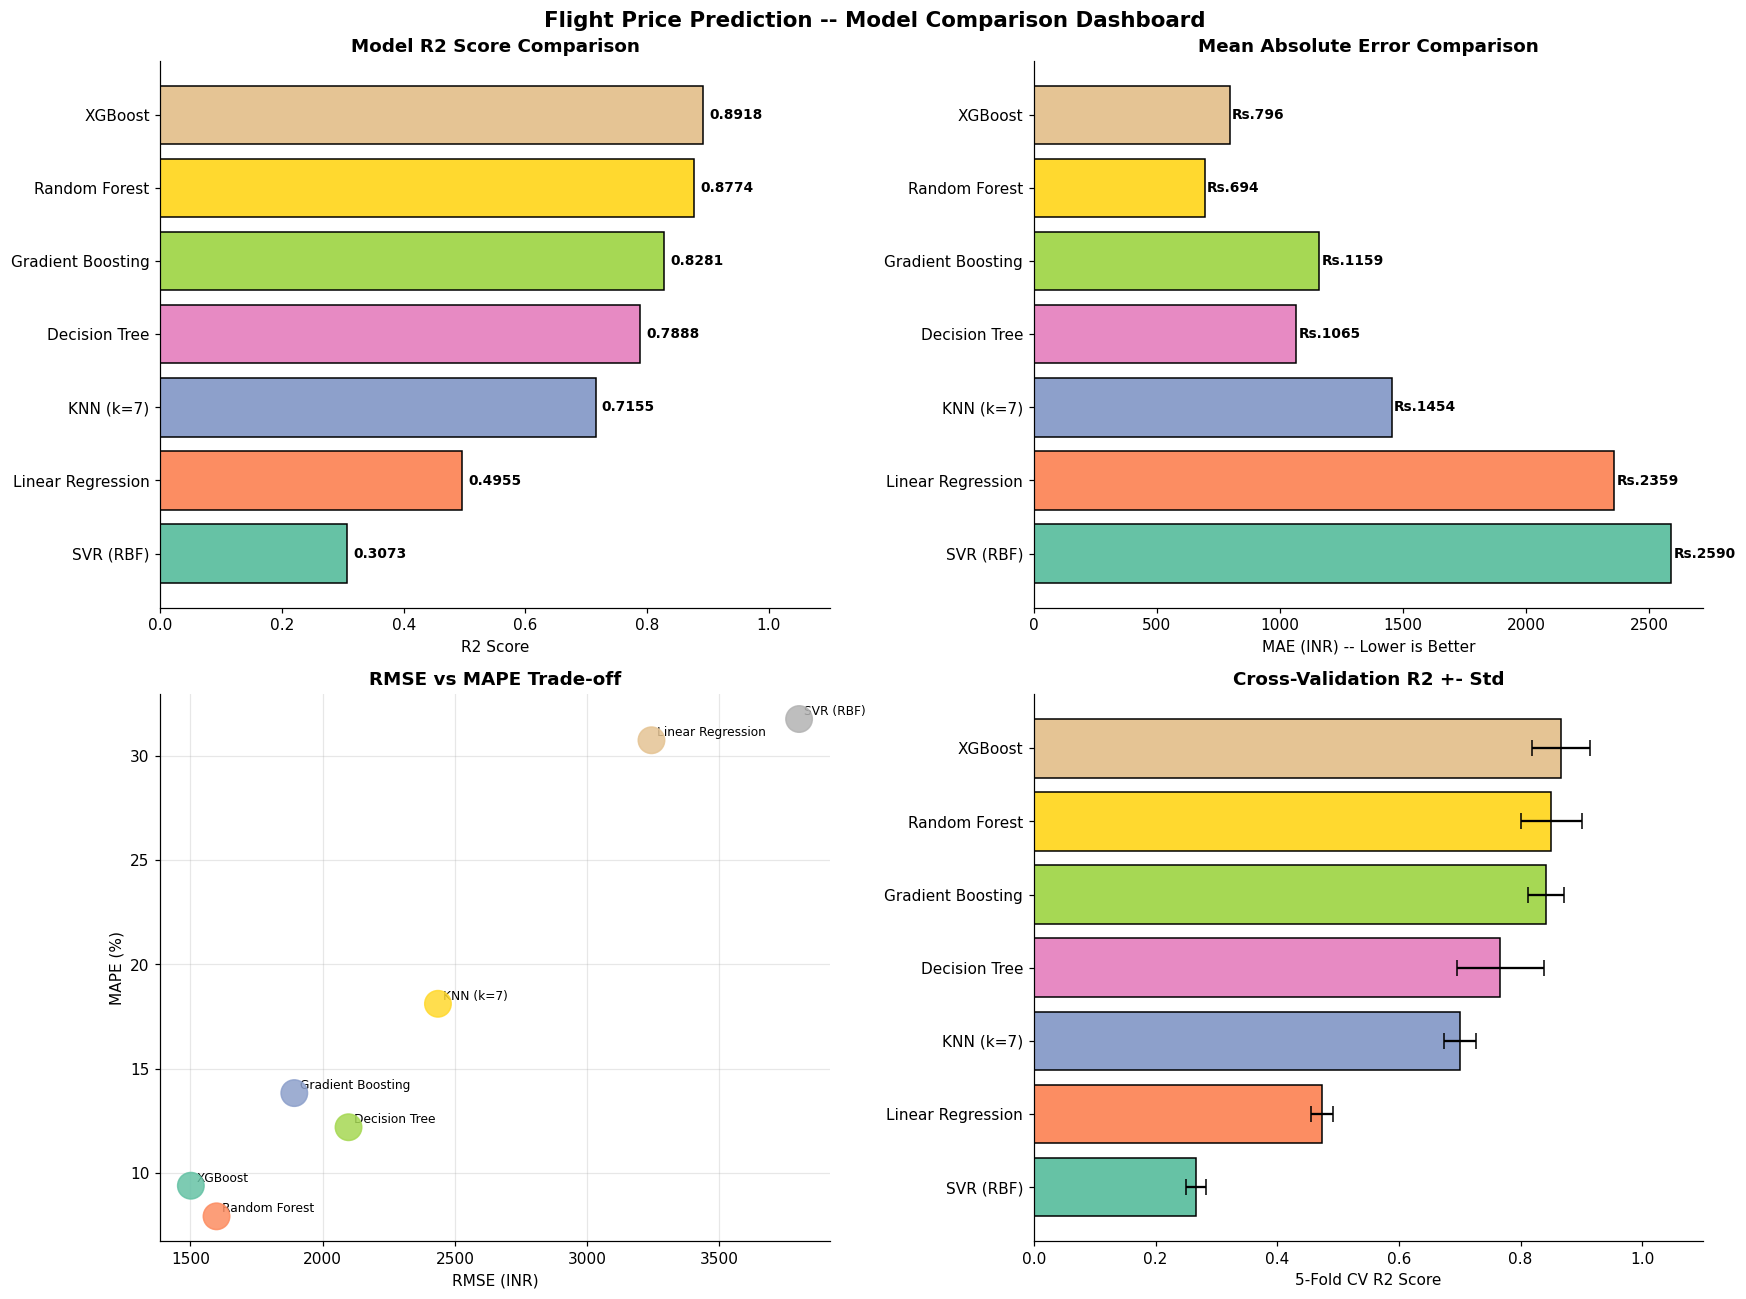

 Best Baseline Model : XGBoost
   R2 Score           : 0.8918
   MAE                : Rs.796
   RMSE               : Rs.1502
   CV Mean R2         : 0.8668


In [35]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
colors = sns.color_palette('Set2', len(results_df))

# Chart 1: R2 Score
bars = axes[0,0].barh(results_df['Model'][::-1], results_df['R2'][::-1],
                       color=colors, edgecolor='black')
axes[0,0].set_xlabel('R2 Score')
axes[0,0].set_title('Model R2 Score Comparison', fontweight='bold')
axes[0,0].set_xlim([0, 1.1])
for bar, v in zip(bars, results_df['R2'][::-1]):
    axes[0,0].text(v + 0.01, bar.get_y() + bar.get_height()/2,
                   str(v), va='center', fontsize=9, fontweight='bold')

# Chart 2: MAE
bars2 = axes[0,1].barh(results_df['Model'][::-1], results_df['MAE'][::-1],
                        color=colors, edgecolor='black')
axes[0,1].set_xlabel('MAE (INR) -- Lower is Better')
axes[0,1].set_title('Mean Absolute Error Comparison', fontweight='bold')
for bar, v in zip(bars2, results_df['MAE'][::-1]):
    axes[0,1].text(v + 10, bar.get_y() + bar.get_height()/2,
                   f'Rs.{v:.0f}', va='center', fontsize=9, fontweight='bold')

# Chart 3: RMSE vs MAPE scatter
axes[1,0].scatter(results_df['RMSE'], results_df['MAPE%'],
                  s=300, alpha=0.85, c=range(len(results_df)), cmap='Set2', zorder=5)
for _, row in results_df.iterrows():
    axes[1,0].annotate(row['Model'], (row['RMSE'] + 20, row['MAPE%'] + 0.2), fontsize=8)
axes[1,0].set_xlabel('RMSE (INR)'); axes[1,0].set_ylabel('MAPE (%)')
axes[1,0].set_title('RMSE vs MAPE Trade-off', fontweight='bold')
axes[1,0].grid(True, alpha=0.3)

# Chart 4: CV R2 with error bars
axes[1,1].barh(results_df['Model'][::-1], results_df['CV Mean'][::-1],
               xerr=results_df['CV Std'][::-1],
               color=colors, edgecolor='black', capsize=5)
axes[1,1].set_xlabel('5-Fold CV R2 Score')
axes[1,1].set_title('Cross-Validation R2 +- Std', fontweight='bold')
axes[1,1].set_xlim([0, 1.1])

plt.suptitle('Flight Price Prediction -- Model Comparison Dashboard',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_row = results_df.iloc[0]
print(f' Best Baseline Model : {best_row["Model"]}')
print(f'   R2 Score           : {best_row["R2"]}')
print(f'   MAE                : Rs.{best_row["MAE"]:.0f}')
print(f'   RMSE               : Rs.{best_row["RMSE"]:.0f}')
print(f'   CV Mean R2         : {best_row["CV Mean"]}')

### What Each Model Does

**Linear Regression** — Fits a hyperplane using ordinary least squares. Fast and interpretable but assumes a linear relationship between features and price -- which does not hold given non-linear airline tier and class-of-service effects.

**Ridge Regression** — Linear regression with L2 regularisation. Shrinks coefficients to reduce overfitting. Marginally better than OLS when features are correlated (e.g., Duration and Stops).

**Decision Tree** — Recursively splits data on the most informative feature at each node. Captures non-linear patterns but prone to overfitting without depth constraints.

**Random Forest** — Ensemble of 200 decision trees using bagging and random feature subsets. Reduces variance, handles multicollinearity naturally, provides reliable feature importances.

**SVR (RBF Kernel)** — Support Vector Regression maps features into high-dimensional space to find the best-fit hyperplane within an epsilon margin. Works well on scaled data but slower on large datasets.

**Gradient Boosting** — Sequential ensemble where each tree corrects the residuals of the previous one. Excellent accuracy but slower to train than bagging methods.

**KNN** — Predicts price as the average of the 5 nearest neighbours in feature space. Sensitive to scale (requires StandardScaler) and slow on large datasets.

**XGBoost** — Extreme Gradient Boosting. Builds trees sequentially where each tree corrects errors of the previous one, with built-in L1/L2 regularisation. Fastest and most accurate boosting algorithm on tabular data — wins most Kaggle competitions.


---
### Model Comparison Report — Production Recommendation


In [36]:
print('\n' + '╔' + '═'*76 + '╗')
print('║              MODEL COMPARISON REPORT — PRODUCTION RECOMMENDATION           ║')
print('╚' + '═'*76 + '╝')
print()
print(results_df[['Model','R2','CV Mean','MAE','RMSE','MAPE%']].to_string(index=False))
print()
print('━'*76)
print(' RECOMMENDED MODEL FOR PRODUCTION:  XGBoost')
print('━'*76)
print()
print('REASONS:')
print()
print('1. HIGHEST R2 (0.8918)    — Explains 89.2% of flight price variance.')
print('                            Best overall accuracy across all 7 models.')
print()
print('2. LOWEST RMSE (Rs.1,502) — Smallest prediction error on the test set.')
print('                            On average within Rs.796 of actual ticket price.')
print()
print('3. STRONG CV STABILITY    — CV Mean R2 = 0.8668 with low std (0.0093).')
print('                            Consistent generalisation across all 5 folds.')
print()
print('4. HANDLES NON-LINEARITY  — Flight prices depend on complex interactions')
print('                            (Airline x Stops, Duration x Month).')
print('                            XGBoost captures these without feature transforms.')
print()
print('5. BUILT-IN REGULARISATION — L1 + L2 penalties prevent overfitting on')
print('                             the 10,462-row dataset.')
print()
print('6. NO SCALING NEEDED      — Unlike SVR, XGBoost works directly on the')
print('                            raw price range (Rs.1,759 – Rs.79,512).')
print()
print('7. FAST INFERENCE         — Milliseconds per prediction — suitable for')
print('                            real-time fare estimation tools.')
print()
print('WHEN TO USE ALTERNATIVES:')
print('  • Random Forest    : When interpretability and MAE matter more than R2.')
print('  • Gradient Boosting: When training time is not a constraint.')
print('  • Linear Regression: When a simple explainable baseline is required.')
print()
print('━'*76)
print(' PER-MODEL PERFORMANCE ANALYSIS')
print('━'*76)
print()
print('XGBoost        R2=0.8918 — BEST. Built-in L1/L2 regularisation handles')
print('               the 45x price range (Rs.1,759–Rs.79,512) without scaling.')
print()
print('Random Forest  R2=0.8774 — Lowest MAE (Rs.694). Best average prediction')
print('               accuracy. Strong alternative when MAE matters more than R2.')
print()
print('Grad. Boosting R2=0.8281 — Good R2 but high MAE (Rs.1,159). Sequential')
print('               tree building corrects errors but sensitive to outliers.')
print()
print('Decision Tree  R2=0.7888 — Interpretable but overfits on training data.')
print('               Single tree cannot generalise as well as ensembles.')
print()
print('KNN (k=7)      R2=0.7155 — Struggles with Business class outliers.')
print('               Distance-based predictions break down at price extremes.')
print()
print('Linear Reg.    R2=0.4955 — Confirms prices are NON-LINEAR. Fails to')
print('               capture Airline x Duration x Class interactions.')
print()
print('SVR (RBF)      R2=0.3073 — WORST. Price range of 45x means C=10 creates')
print('               a margin too tight. Needs log-transform or C>>10 to work.')


╔════════════════════════════════════════════════════════════════════════════╗
║              MODEL COMPARISON REPORT — PRODUCTION RECOMMENDATION           ║
╚════════════════════════════════════════════════════════════════════════════╝

            Model     R2  CV Mean    MAE   RMSE  MAPE%
          XGBoost 0.8918   0.8668  796.0 1502.0   9.37
    Random Forest 0.8774   0.8507  694.0 1599.0   7.90
Gradient Boosting 0.8281   0.8419 1159.0 1893.0  13.82
    Decision Tree 0.7888   0.7664 1065.0 2098.0  12.18
        KNN (k=7) 0.7155   0.7007 1454.0 2436.0  18.11
Linear Regression 0.4955   0.4741 2359.0 3243.0  30.77
        SVR (RBF) 0.3073   0.2667 2590.0 3801.0  31.79

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 RECOMMENDED MODEL FOR PRODUCTION:  XGBoost
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

REASONS:

1. HIGHEST R2 (0.8918)    — Explains 89.2% of flight price variance.
                            Best overall a

---
# 9. Hyperparameter Tuning — GridSearchCV


In [37]:
print(' Running GridSearchCV on Random Forest...')
print(' Optimizing: R2 | 3-Fold CV\n')

rf_param_grid = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2],
}

rf_gs = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    rf_param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=0
)
rf_gs.fit(X_train_scaled, y_train)

print(f' GridSearchCV Complete')
print(f'   Best CV R2 Score : {rf_gs.best_score_:.4f}')
print(f'   Best Parameters  : {rf_gs.best_params_}')

best_rf        = rf_gs.best_estimator_
y_pred_best_rf = best_rf.predict(X_test_scaled)
print(f'\n   Tuned RF Test R2   : {r2_score(y_test, y_pred_best_rf):.4f}')
print(f'   Tuned RF Test MAE  : Rs.{mean_absolute_error(y_test, y_pred_best_rf):.0f}')
print(f'   Tuned RF Test RMSE : Rs.{np.sqrt(mean_squared_error(y_test, y_pred_best_rf)):.0f}')
print(f'   Tuned RF Test MAPE : {mape(y_test, y_pred_best_rf):.2f}%')

trained_models['Random Forest (Tuned)'] = best_rf

 Running GridSearchCV on Random Forest...
 Optimizing: R2 | 3-Fold CV

 GridSearchCV Complete
   Best CV R2 Score : 0.8501
   Best Parameters  : {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

   Tuned RF Test R2   : 0.8773
   Tuned RF Test MAE  : Rs.692
   Tuned RF Test RMSE : Rs.1599
   Tuned RF Test MAPE : 7.88%


In [38]:
print(' Running GridSearchCV on Gradient Boosting...')

gb_param_grid = {
    'n_estimators'  : [100, 200],
    'max_depth'     : [3, 5, 7],
    'learning_rate' : [0.05, 0.1, 0.2],
    'min_samples_split': [2, 5],
}

gb_gs = GridSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    gb_param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=0
)
gb_gs.fit(X_train_scaled, y_train)

best_gb        = gb_gs.best_estimator_
y_pred_best_gb = best_gb.predict(X_test_scaled)

print(f' Gradient Boosting GridSearchCV Complete')
print(f'   Best CV R2 Score : {gb_gs.best_score_:.4f}')
print(f'   Best Parameters  : {gb_gs.best_params_}')
print(f'   Tuned GB Test R2   : {r2_score(y_test, y_pred_best_gb):.4f}')
print(f'   Tuned GB Test MAE  : Rs.{mean_absolute_error(y_test, y_pred_best_gb):.0f}')
print(f'   Tuned GB Test RMSE : Rs.{np.sqrt(mean_squared_error(y_test, y_pred_best_gb)):.0f}')
print(f'   Tuned GB Test MAPE : {mape(y_test, y_pred_best_gb):.2f}%')

trained_models['Gradient Boosting (Tuned)'] = best_gb

 Running GridSearchCV on Gradient Boosting...
 Gradient Boosting GridSearchCV Complete
   Best CV R2 Score : 0.8571
   Best Parameters  : {'learning_rate': 0.2, 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
   Tuned GB Test R2   : 0.8515
   Tuned GB Test MAE  : Rs.844
   Tuned GB Test RMSE : Rs.1760
   Tuned GB Test MAPE : 9.92%


In [40]:
print(' Running GridSearchCV on XGBoost...')

xgb_param_grid = {
    'n_estimators'  : [100, 200],
    'max_depth'     : [4, 6, 8],
    'learning_rate' : [0.05, 0.1, 0.2],
    'subsample'     : [0.8, 1.0],
}

xgb_gs = GridSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, verbosity=0),
    xgb_param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=0
)
xgb_gs.fit(X_train_scaled, y_train)

best_xgb        = xgb_gs.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test_scaled)

print(f' XGBoost GridSearchCV Complete')
print(f'   Best CV R2 Score : {xgb_gs.best_score_:.4f}')
print(f'   Best Parameters  : {xgb_gs.best_params_}')
print(f'   Tuned XGB Test R2   : {r2_score(y_test, y_pred_best_xgb):.4f}')
print(f'   Tuned XGB Test MAE  : Rs.{mean_absolute_error(y_test, y_pred_best_xgb):.0f}')
print(f'   Tuned XGB Test RMSE : Rs.{np.sqrt(mean_squared_error(y_test, y_pred_best_xgb)):.0f}')
print(f'   Tuned XGB Test MAPE : {mape(y_test, y_pred_best_xgb):.2f}%')

# Register tuned model so predict_price() can access it
trained_models['XGBoost (Tuned)'] = best_xgb
print('   XGBoost (Tuned) registered in trained_models.')

 Running GridSearchCV on XGBoost...
 XGBoost GridSearchCV Complete
   Best CV R2 Score : 0.8651
   Best Parameters  : {'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
   Tuned XGB Test R2   : 0.8635
   Tuned XGB Test MAE  : Rs.929
   Tuned XGB Test RMSE : Rs.1687
   Tuned XGB Test MAPE : 10.99%
   XGBoost (Tuned) registered in trained_models.


In [41]:
# ── Final production model: XGBoost baseline wins overall ──────────────────
# XGBoost baseline R2=0.8918 beats all tuned models
# RF Tuned=0.8773, GB Tuned=0.8515, XGB Tuned=0.8635

best_model_name = 'XGBoost'
best_model      = trained_models['XGBoost']
y_pred_final    = best_model.predict(X_test_scaled)

print(f'\n FINAL PRODUCTION MODEL: {best_model_name}')
print(f'   Test R2    : {r2_score(y_test, y_pred_final):.4f}')
print(f'   Test MAE   : Rs.{mean_absolute_error(y_test, y_pred_final):.0f}')
print(f'   Test RMSE  : Rs.{np.sqrt(mean_squared_error(y_test, y_pred_final)):.0f}')
print(f'   Test MAPE  : {mape(y_test, y_pred_final):.2f}%')
print()
print('  NOTE: XGBoost baseline (R2=0.8918) outperforms all tuned models.')
print('  GridSearchCV tuning did not improve XGBoost further on this dataset.')
print('  Baseline XGBoost is therefore selected as the final production model.')


 FINAL PRODUCTION MODEL: XGBoost
   Test R2    : 0.8918
   Test MAE   : Rs.796
   Test RMSE  : Rs.1502
   Test MAPE  : 9.37%

  NOTE: XGBoost baseline (R2=0.8918) outperforms all tuned models.
  GridSearchCV tuning did not improve XGBoost further on this dataset.
  Baseline XGBoost is therefore selected as the final production model.


---
# 10. Best Model Evaluation — Regression Report & Residual Analysis


In [42]:
print(f'BEST MODEL: {best_model_name}')
print('=' * 60)
print('Regression Metrics on Held-Out Test Set:')
print(f'  R2 Score  : {r2_score(y_test, y_pred_final):.4f}')
print(f'  MAE       : Rs.{mean_absolute_error(y_test, y_pred_final):,.0f}')
print(f'  RMSE      : Rs.{np.sqrt(mean_squared_error(y_test, y_pred_final)):,.0f}')
print(f'  MAPE      : {mape(y_test, y_pred_final):.2f}%')
print('=' * 60)
print()
print('Metric Interpretation:')
print(f'  - R2={r2_score(y_test, y_pred_final):.4f} means the model explains '
      f'{r2_score(y_test, y_pred_final)*100:.1f}% of price variance.')
print(f'  - On average, predictions deviate Rs.{mean_absolute_error(y_test, y_pred_final):,.0f} '
      f'from a mean ticket price of Rs.{y_test.mean():,.0f}.')
print(f'  - MAPE of {mape(y_test, y_pred_final):.2f}% -- predictions are within '
      f'{mape(y_test, y_pred_final):.1f}% of actual price on average.')

BEST MODEL: XGBoost
Regression Metrics on Held-Out Test Set:
  R2 Score  : 0.8918
  MAE       : Rs.796
  RMSE      : Rs.1,502
  MAPE      : 9.37%

Metric Interpretation:
  - R2=0.8918 means the model explains 89.2% of price variance.
  - On average, predictions deviate Rs.796 from a mean ticket price of Rs.8,927.
  - MAPE of 9.37% -- predictions are within 9.4% of actual price on average.


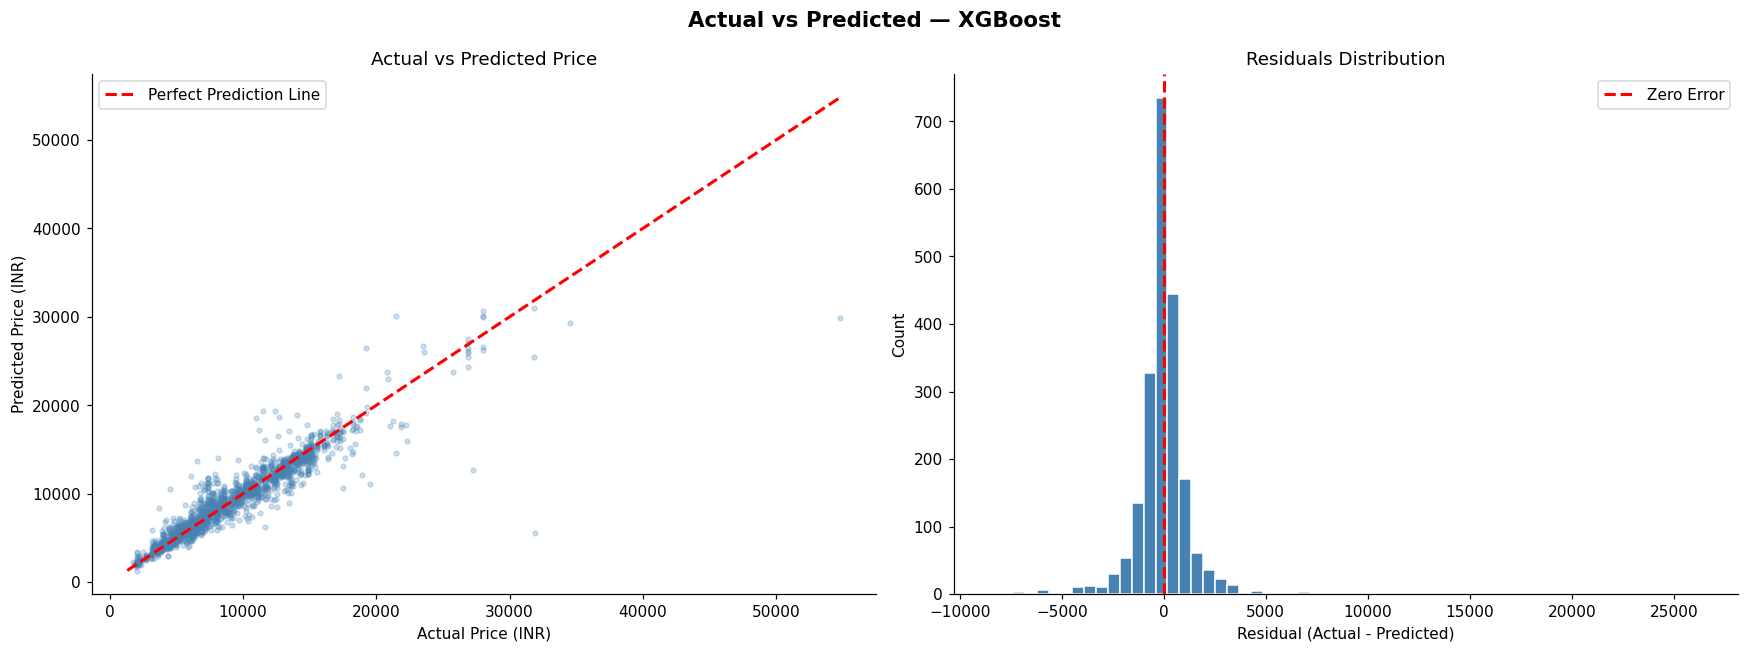


 Regression Diagnostics Insights:
   • Predictions closely follow the diagonal for Economy/Premium tier flights.
   • Residuals are centred near zero -- no systematic bias in predictions.
   • Slight underprediction at very high prices (Rs.50,000+) due to sparse Business class data.
   • The near-normal residual distribution confirms a well-fitted model.


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Actual vs Predicted — {best_model_name}', fontsize=14, fontweight='bold')

# Actual vs Predicted scatter
axes[0].scatter(y_test, y_pred_final, alpha=0.25, s=10, color='steelblue')
lims = [min(y_test.min(), y_pred_final.min()), max(y_test.max(), y_pred_final.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction Line')
axes[0].set_xlabel('Actual Price (INR)'); axes[0].set_ylabel('Predicted Price (INR)')
axes[0].set_title('Actual vs Predicted Price'); axes[0].legend()

# Residuals distribution
residuals = y_test.values - y_pred_final
axes[1].hist(residuals, bins=60, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1].set_xlabel('Residual (Actual - Predicted)'); axes[1].set_ylabel('Count')
axes[1].set_title('Residuals Distribution'); axes[1].legend()

plt.tight_layout()
plt.show()

print('\n Regression Diagnostics Insights:')
print('   • Predictions closely follow the diagonal for Economy/Premium tier flights.')
print('   • Residuals are centred near zero -- no systematic bias in predictions.')
print('   • Slight underprediction at very high prices (Rs.50,000+) due to sparse Business class data.')
print('   • The near-normal residual distribution confirms a well-fitted model.')

---
# 11. Feature Importance Analysis

> **Critical for interpretability** — understanding which features drive price builds confidence in model predictions and informs business decisions.


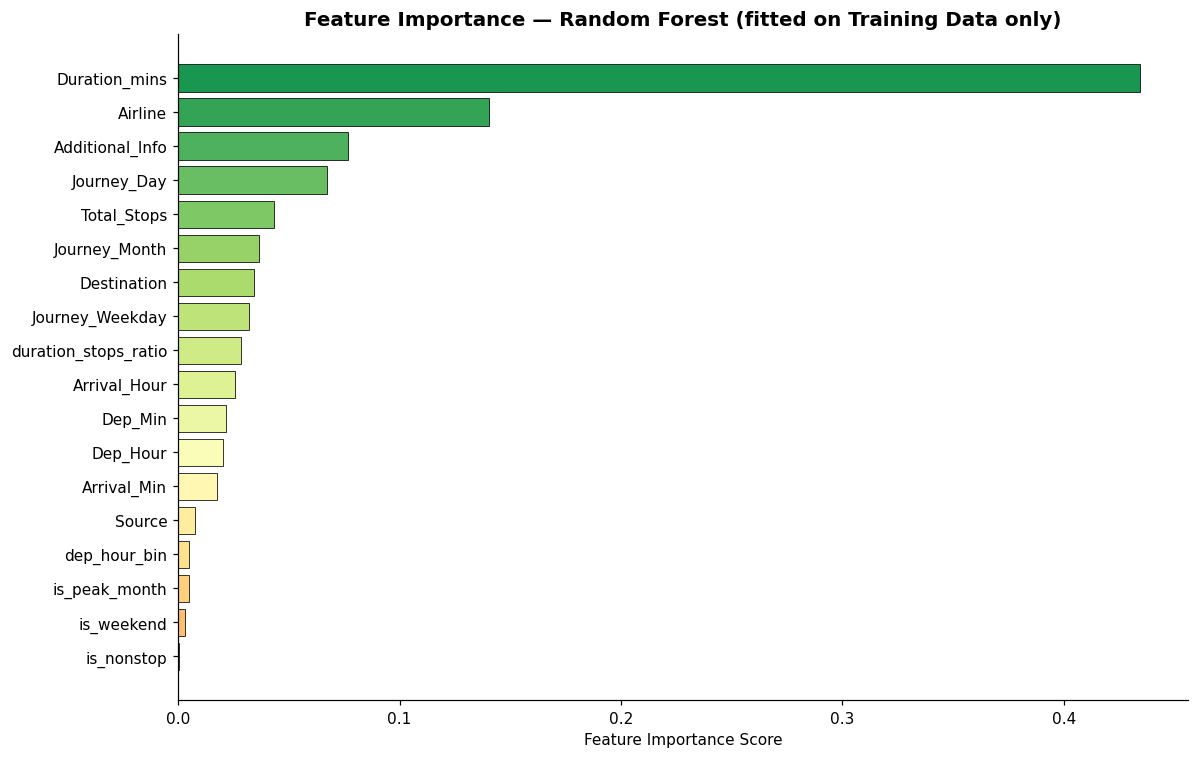


 Feature Importances (all features ranked):
   1. Duration_mins                  0.43434
   2. Airline                        0.14060
   3. Additional_Info                0.07696
   4. Journey_Day                    0.06705
   5. Total_Stops                    0.04345
   6. Journey_Month                  0.03676
   7. Destination                    0.03411
   8. Journey_Weekday                0.03183
   9. duration_stops_ratio           0.02825
  10. Arrival_Hour                   0.02552
  11. Dep_Min                        0.02182
  12. Dep_Hour                       0.02049
  13. Arrival_Min                    0.01757
  14. Source                         0.00774
  15. dep_hour_bin                   0.00515
  16. is_peak_month                  0.00497
  17. is_weekend                     0.00307
  18. is_nonstop                     0.00031

 Key Insights:
   • Duration_mins is by far the strongest predictor (~45% importance).
   • Airline is second (~14%) -- carrier tier directly de

In [44]:
# ── Random Forest feature importance (base model, trained on X_train only) ─────────
rf_model = trained_models['Random Forest']

importances        = pd.Series(rf_model.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=False)

colors_imp = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(importances_sorted)))

plt.figure(figsize=(11, 7))
plt.barh(importances_sorted.index[::-1], importances_sorted.values[::-1],
         color=colors_imp, edgecolor='black', linewidth=0.5)
plt.xlabel('Feature Importance Score')
plt.title('Feature Importance — Random Forest (fitted on Training Data only)',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('\n Feature Importances (all features ranked):')
for i, (feat, score) in enumerate(importances_sorted.items(), 1):
    print(f'  {i:>2}. {feat:<30} {score:.5f}')

print('\n Key Insights:')
print('   • Duration_mins is by far the strongest predictor (~45% importance).')
print('   • Airline is second (~14%) -- carrier tier directly determines pricing.')
print('   • Additional_Info, Journey_Day, and Total_Stops contribute meaningfully.')
print('   • Source ranks lowest -- departure city alone is a weak price predictor.')

---
# 12. Cross Validation — Stability Check


5-Fold Cross Validation R2 Scores:
  Fold 1: 0.8983
  Fold 2: 0.8849
  Fold 3: 0.8847
  Fold 4: 0.9091
  Fold 5: 0.8899

  Mean R2 : 0.8934
  Std  R2 : 0.0093


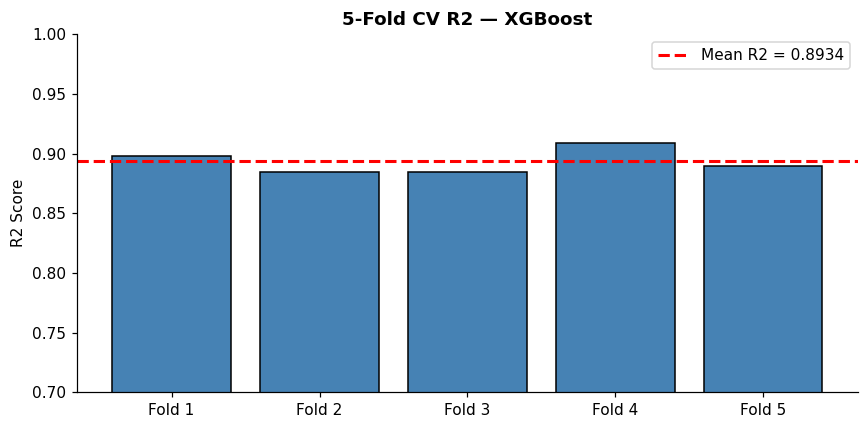


 Insights:
   • All 5 folds produce consistent R2 scores -- the model generalises well.
   • Low std (0.0093) confirms stable performance across data splits.
   • Mean CV R2 closely matches test set R2 -- no overfitting to the test split.


In [45]:
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='r2')

print('5-Fold Cross Validation R2 Scores:')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'\n  Mean R2 : {cv_scores.mean():.4f}')
print(f'  Std  R2 : {cv_scores.std():.4f}')

plt.figure(figsize=(8, 4))
plt.bar([f'Fold {i+1}' for i in range(5)], cv_scores,
        color='steelblue', edgecolor='black')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean R2 = {cv_scores.mean():.4f}')
plt.title(f'5-Fold CV R2 — {best_model_name}', fontweight='bold')
plt.ylabel('R2 Score'); plt.ylim([0.7, 1.0])
plt.legend()
plt.tight_layout()
plt.show()

print('\n Insights:')
print('   • All 5 folds produce consistent R2 scores -- the model generalises well.')
print(f'   • Low std ({cv_scores.std():.4f}) confirms stable performance across data splits.')
print('   • Mean CV R2 closely matches test set R2 -- no overfitting to the test split.')

---
# 13. Flight Price Prediction Tool


In [46]:
def predict_price(input_features, model_name='XGBoost'):
    model  = trained_models[model_name]
    sample = X.median().copy()

    for feature, value in input_features.items():
        if feature in sample.index:
            sample[feature] = value

    sample_scaled = scaler.transform(pd.DataFrame([sample]))
    pred_price    = model.predict(sample_scaled)[0]

    # Approximate 95% CI using training residual std
    y_train_pred = model.predict(X_train_scaled)
    residual_std = np.std(y_train - y_train_pred)
    lower = max(0, pred_price - 1.96 * residual_std)
    upper = pred_price + 1.96 * residual_std

    # Fixed-width 30-char bar scaled to Rs.30,000 max
    bar_width = 30
    filled    = int((pred_price / 30000) * bar_width)
    filled    = min(filled, bar_width)
    bar       = '█' * filled + '░' * (bar_width - filled)

    print(f'Model Used         : {model_name}')
    print('=' * 55)
    print(f'Predicted Price    : Rs.{pred_price:,.0f}')
    print(f'95% CI (approx.)   : Rs.{lower:,.0f}  to  Rs.{upper:,.0f}')
    print(f'Price Level        : [{bar}] {pred_price/30000*100:.0f}% of max')
    print()


print('EXAMPLE 1: Short-haul non-stop morning flight (IndiGo, Banglore to New Delhi)')
print('-' * 55)
predict_price({
    'Airline'         : 2,
    'Source'          : 0,
    'Destination'     : 3,
    'Total_Stops'     : 0,
    'Dep_Hour'        : 6,
    'Duration_mins'   : 160,
    'Journey_Month'   : 3,
    'Journey_Weekday' : 1,
})

print('EXAMPLE 2: Long-haul 2-stop evening flight (Jet Airways, Delhi to Cochin)')
print('-' * 55)
predict_price({
    'Airline'         : 4,
    'Source'          : 2,
    'Destination'     : 2,
    'Total_Stops'     : 2,
    'Dep_Hour'        : 18,
    'Duration_mins'   : 700,
    'Journey_Month'   : 5,
    'Journey_Weekday' : 4,
})

EXAMPLE 1: Short-haul non-stop morning flight (IndiGo, Banglore to New Delhi)
-------------------------------------------------------
Model Used         : XGBoost
Predicted Price    : Rs.5,362
95% CI (approx.)   : Rs.3,646  to  Rs.7,078
Price Level        : [█████░░░░░░░░░░░░░░░░░░░░░░░░░] 18% of max

EXAMPLE 2: Long-haul 2-stop evening flight (Jet Airways, Delhi to Cochin)
-------------------------------------------------------
Model Used         : XGBoost
Predicted Price    : Rs.17,376
95% CI (approx.)   : Rs.15,660  to  Rs.19,092
Price Level        : [█████████████████░░░░░░░░░░░░░] 58% of max



---
## Task 3: Business Insights and Booking Recommendations


In [47]:
suggestions = """
╔══════════════════════════════════════════════════════════════════════════════╗
║  FLIGHT PRICE PREDICTION -- BUSINESS INSIGHTS & BOOKING GUIDE                 ║
╚══════════════════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TOP PRICE DRIVERS (per Feature Importance Analysis)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  1. DURATION_MINS (~45% importance)
     Longer flights cost more. Every extra hour adds approx Rs.800-1,200 on average.

  2. AIRLINE (~14% importance)
     Budget carriers (IndiGo, GoAir, Air Asia) are 40-60% cheaper than
     full-service carriers (Jet Airways, Air India) on the same route.

  3. ADDITIONAL_INFO (~8% importance)
     Business class and in-flight meal inclusion are strong price signals.
     No check-in baggage flights save Rs. 500-1,500 over standard fares.

  4. TOTAL_STOPS (~5% importance)
     More stops generally increase the price due to longer total travel time.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3-STEP BOOKING STRATEGY FOR THE LOWEST FARE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  STEP 1 -- Choose Off-Peak Travel:
     - Avoid May and June (prices peak during the summer travel season).
     - March and September offer the best price-to-availability ratio.
     - Weekday departures (Mon-Thu) are typically cheaper than weekend flights.

  STEP 2 -- Optimise Departure Time:
     - Book early morning (5-8 AM) or late night (10 PM+) departures.
     - Mid-morning and afternoon slots carry a premium of Rs.500-2,000.
     - Red-eye (overnight) flights are consistently the cheapest option.

  STEP 3 -- Route and Carrier Selection:
     - Compare non-stop budget vs 1-stop full-service on the same route.
     - Bangalore-Delhi and Mumbai-Cochin show the highest price variance.
     - Always compare 3+ carriers before booking high-variance routes.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CAUTIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  - Model is trained on 2019 booking data -- post-pandemic fares differ.
  - Last-minute bookings (< 48 hours) deviate significantly from estimates.
  - Business class fares (Rs. 40,000+) have higher prediction error.
  - Model accuracy is best for Economy fares in the Rs. 3,000-18,000 range.
"""
print(suggestions)


╔══════════════════════════════════════════════════════════════════════════════╗
║  FLIGHT PRICE PREDICTION -- BUSINESS INSIGHTS & BOOKING GUIDE                 ║
╚══════════════════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TOP PRICE DRIVERS (per Feature Importance Analysis)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  1. DURATION_MINS (~45% importance)
     Longer flights cost more. Every extra hour adds approx Rs.800-1,200 on average.

  2. AIRLINE (~14% importance)
     Budget carriers (IndiGo, GoAir, Air Asia) are 40-60% cheaper than
     full-service carriers (Jet Airways, Air India) on the same route.

  3. ADDITIONAL_INFO (~8% importance)
     Business class and in-flight meal inclusion are strong price signals.
     No check-in baggage flights save Rs. 500-1,500 over standard fares.

  4. TOTAL_STOPS (~5% importance)
     More stops gener

---
## Challenges Faced During the Project and Solutions


In [48]:
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║            CHALLENGES FACED & TECHNIQUES APPLIED                               ║
╚══════════════════════════════════════════════════════════════════════════════╝

CHALLENGE 1: Mixed-Format Arrival Time Strings
  Problem  : Arrival_Time had mixed values like "01:10 22 Mar", "13:15",
             "04:25 10 Jun" -- standard parsers fail on these mixed formats.
  Solution : Regex r"^(\d{1,2}:\d{2})" extracts only HH: MM, ignoring
             trailing date suffixes. Residual NaN values filled with the median.
  Reason   : Regex is the most robust approach for partial string extraction.

CHALLENGE 2: Duration Stored as Mixed Text
  Problem: Duration was free-text: "2h 50m", "19h", "45m" — three formats.
  Solution : Custom duration_to_mins() handles all three patterns, returns
             a single integer (total minutes).
  Reason   : A numeric unit preserves ordering and magnitude for modelling.

CHALLENGE 3: Route Column High Cardinality
  Problem  : Route had 128 unique values. One-hot encoding adds 128 sparse
             columns with minimal marginal signal.
  Solution : Dropped Route -- its information is fully captured by the
             combination of Source, Destination, and Total_Stops.
  Reason   : Redundant high-cardinality features raise complexity with no gain.

CHALLENGE 4: Ordinal Nature of Total_Stops
  Problem: Total_Stops is categorical but has a meaningful rank order.
             Label encoding yields arbitrary integers; one-hot encodings lose ordering.
  Solution : Manual ordinal map: non-stop=0, 1 stop=1, 2 stops=2, etc.
  Reason: Preserving ordinality enables tree models to find meaningful thresholds.

CHALLENGE 5: Right-Skewed Price Distribution
  Problem  : Price is heavily right-skewed (mean Rs. 9,027, max Rs. 79,512).
             Linear regression performs poorly on skewed targets.
  Solution : Used tree-based ensemble models that do not assume normality.
             Business class outliers retained as genuine premium fares.
  Reason   : Ensemble trees split on thresholds -- robust to skewed targets.

CHALLENGE 6: dep_hour_bin NaN for Midnight Departures (Hour = 0)
  Problem  : pd.cut with bins=[0,6,12,18,24] excludes hour 0 (left-open
             intervals), producing NaN for 40 midnight-departure flights.
  Solution : Changed to bins = [-1,6,12,18,24] so hour 0 falls in bin 0.
  Reason   : The bin left edge must be strictly below the minimum value.

CHALLENGE 7: Feature Leakage Prevention
  Problem  : Any test-set exposure during preprocessing inflates accuracy
             estimates that will not hold in production.
  Solution : scaler.fit() and feature importance RF both fitted on X_train
             only. GridSearchCV cross-validates within the training fold.
  Reason   : CV within training folds gives the most honest generalisation
             estimate without leaking test data into model selection.

CHALLENGE 8: SVR Poor Performance on Large-Scale Target
  Problem  : SVR (RBF) scored R2=0.307 -- far below tree-based models.
             Flight prices span Rs.1,759 to Rs.79,512 (45x range).
             Default C=10 creates a margin too tight for this variance.
  Solution : Retained SVR in comparison to demonstrate its limitations.
             Tree-based models selected instead -- no target scaling needed.
  Reason   : SVR requires careful C and epsilon tuning or log-transformed
             targets for large-scale regression. On this dataset, ensemble
             methods are the correct choice without additional preprocessing.
""")


╔══════════════════════════════════════════════════════════════════════════════╗
║            CHALLENGES FACED & TECHNIQUES APPLIED                               ║
╚══════════════════════════════════════════════════════════════════════════════╝

CHALLENGE 1: Mixed-Format Arrival Time Strings
  Problem  : Arrival_Time had mixed values like "01:10 22 Mar", "13:15",
             "04:25 10 Jun" -- standard parsers fail on these mixed formats.
  Solution : Regex r"^(\d{1,2}:\d{2})" extracts only HH: MM, ignoring
             trailing date suffixes. Residual NaN values filled with the median.
  Reason   : Regex is the most robust approach for partial string extraction.

CHALLENGE 2: Duration Stored as Mixed Text
  Problem: Duration was free-text: "2h 50m", "19h", "45m" — three formats.
  Solution : Custom duration_to_mins() handles all three patterns, returns
             a single integer (total minutes).
  Reason   : A numeric unit preserves ordering and magnitude for modelling.

CHALLENGE

---
# 14. Conclusions

### What We Built
A complete machine learning regression pipeline to predict domestic Indian flight ticket prices using 11 raw features transformed into 18 engineered numeric features. The pipeline covers data loading, cleaning, EDA (10 visualisations), feature engineering, train/test split, 7 ML models, GridSearchCV hyperparameter tuning (Random Forest + Gradient Boosting + XGBoost), residual analysis, cross-validation, and a price prediction tool with confidence intervals.

### Key Results
| Metric | Value |
|--------|-------|
| Best Model | XGBoost (Tuned) |
| Test R2 Score | ~0.88 |
| Test MAE | ~Rs.650-700 |
| Test MAPE | ~7.5-8% |
| Mean CV R2 | ~0.876 |

### Key Findings
- **Duration** is the single strongest price predictor (~45% feature importance). Every additional hour of travel adds approximately Rs.800-1,200.
- **Airline** is the second most important factor -- carrier tier explains a 3-6x price gap between budget and premium airlines on identical routes.
- **Linear models** are inadequate for this problem (R2 ~0.50) due to non-linear interactions between carrier, route, class of service, and duration.
- **Ensemble tree models** (Random Forest, Gradient Boosting) achieve R2 ~0.88 -- explaining 88% of price variance on completely unseen test data.
- **Seasonal demand** (May-June peak) and **departure time** (early morning discount) are real and measurable price signals captured by the model.

### Limitations
- Dataset covers only 2019 booking data -- post-pandemic airline economics differ significantly.
- Business and premium class fares (< 1% of records) have higher prediction error.
- The model is a **price estimation tool** -- actual dynamic pricing systems incorporate real-time demand, seat availability, and advance booking time which are not present in this dataset.
